<a href="https://colab.research.google.com/github/susannatangg/comp646_assignments/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Create directory to store the dataset (optional)
!mkdir -p datasets

# Download the dataset
!wget http://cvssp.org/data/fscoco/fscoco.tar.gz -P datasets/

# Extract the tar.gz file
!tar -xzf datasets/fscoco.tar.gz -C datasets/

print("Dataset downloaded and extracted successfully!")

--2025-04-29 00:58:44--  http://cvssp.org/data/fscoco/fscoco.tar.gz
Resolving cvssp.org (cvssp.org)... 131.227.95.12
Connecting to cvssp.org (cvssp.org)|131.227.95.12|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cvssp.org/data/fscoco/fscoco.tar.gz [following]
--2025-04-29 00:58:45--  https://cvssp.org/data/fscoco/fscoco.tar.gz
Connecting to cvssp.org (cvssp.org)|131.227.95.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2378884718 (2.2G) [application/x-gzip]
Saving to: ‘datasets/fscoco.tar.gz’

fscoco.tar.gz       100%[===================>]   2.21G  21.7MB/s    in 1m 46s  

2025-04-29 01:00:32 (21.3 MB/s) - ‘datasets/fscoco.tar.gz’ saved [2378884718/2378884718]

Dataset downloaded and extracted successfully!


In [ ]:
import os
import cv2
import numpy as np
import shutil
from PIL import Image
from sklearn.model_selection import train_test_split

dataset_path = "datasets/fscoco/"
sketch_dir = os.path.join(dataset_path, "raster_sketches")  # Using sketchycoco instead of raster_sketches
vector_dir = os.path.join(dataset_path, "vector_sketches")
output_dir = os.path.join(dataset_path, "processed_sketches")
output_dir_sub = os.path.join(dataset_path, "processed_sub")

os.makedirs(output_dir, exist_ok=True)

In [ ]:
def preprocess_sketch(img_path, size=(224, 224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
    if img is None:
        print(f"Warning: Unable to read image {img_path}")
        return None  # Return None to prevent errors

    img = cv2.resize(img, size)  # Resize to fixed dimensions
    _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)  # Binarize the image
    img = img / 255.0  # Normalize pixel values
    return img

# Process sketches
for root, _, files in os.walk(sketch_dir):
    for file in files:
        img_path = os.path.join(root, file)
        processed_img = preprocess_sketch(img_path)

        if processed_img is not None:
            # Preserve relative subdirectory structure
            relative_path = os.path.relpath(img_path, sketch_dir)
            save_path = os.path.join(output_dir, relative_path)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)

            cv2.imwrite(save_path, (processed_img * 255).astype('uint8'))
        else:
            print(f"Skipping file: {img_path}")

In [ ]:
def augment_sketch(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Flip image horizontally
    flipped = cv2.flip(img, 1)

    # Rotate image
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, 15, 1.0)
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h))

    return [img, flipped, rotated]

# Apply augmentation
for root, _, files in os.walk(sketch_dir):
    for file in files:
        img_path = os.path.join(sketch_dir, file)
        augmented_images = augment_sketch(img_path)

        if augmented_images:
            for i, aug_img in enumerate(augmented_images):
                aug_filename = f"{os.path.splitext(file)[0]}_aug{i}.png"
                cv2.imwrite(os.path.join(output_dir, aug_filename), aug_img)


In [ ]:
old_dir = 'datasets/fscoco/processed_sketches'
new_dir = 'datasets/fscoco/processed_sub'

# Renaming the directory
os.rename(old_dir, new_dir)

In [ ]:
sketch_files = os.listdir(output_dir_sub)
train_files, temp_files = train_test_split(sketch_files, test_size=0.2, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

In [ ]:
import shutil
import os

# Move files to separate directories
train_dir = "datasets/fscoco/processed_sketches/train"
val_dir = "datasets/fscoco/processed_sketches/val"
test_dir = "datasets/fscoco/processed_sketches/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def move_files_to_target(files, target_dir):
    for file in files:
        file_path = os.path.join(output_dir_sub, file)
        shutil.move(file_path, os.path.join(target_dir, file))

move_files_to_target(train_files, train_dir)
move_files_to_target(val_files, val_dir)
move_files_to_target(test_files, test_dir)

print("Train/Validation/Test split completed.")


Train/Validation/Test split completed.


In [ ]:
# move png images, get rid of all the subfolders
import os
import shutil

processed_sketches_dir = "datasets/fscoco/processed_sketches"

dirs = ['train', 'val', 'test']

for dir_name in dirs:
    dir_path = os.path.join(processed_sketches_dir, dir_name)

    if os.path.isdir(dir_path):
        # Walk through the subdirectories and move the .png files
        for root, dirs, files in os.walk(dir_path):
            for file in files:
                if file.endswith(".png"):
                    old_path = os.path.join(root, file)
                    new_path = os.path.join(dir_path, file)

                    shutil.move(old_path, new_path)

        for root, dirs, files in os.walk(dir_path, topdown=False):
            for dir_name in dirs:
                subfolder_path = os.path.join(root, dir_name)
                if not os.listdir(subfolder_path):
                    shutil.rmtree(subfolder_path)

    else:
        print(f"Directory {dir_path} does not exist.")

print("All PNG files have been moved and subfolders removed.")

All PNG files have been moved and subfolders removed.


In [ ]:
# move txt files, get rid of all the subfolders

text_dir = "datasets/fscoco/text"

for subdir in os.listdir(text_dir):
    subdir_path = os.path.join(text_dir, subdir)

    if os.path.isdir(subdir_path):
        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)

            if file.endswith(".txt"):
                new_path = os.path.join(text_dir, file)
                if os.path.exists(new_path):
                    print(f"Skipping {file} - already exists in {text_dir}")
                else:
                    shutil.move(file_path, new_path)

        os.rmdir(subdir_path)

print("All txt files have been moved, and subfolders have been deleted.")

All txt files have been moved, and subfolders have been deleted.


In [ ]:
# Special tokens for captions
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
PAD_TOKEN = "<PAD>"

class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN}
        self.count = 3  # starting index for new words

    def add_sentence(self, sentence):
        """Add all words in the sentence (string) to the vocabulary."""
        for word in sentence.split():
            self.add_word(word.lower())

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.count
            self.idx2word[self.count] = word
            self.count += 1

    def __len__(self):
        return len(self.word2idx)

    def __contains__(self, word):
        return word in self.word2idx

# Create and populate vocabulary using the Vocabulary class
import os

caption_dir = "datasets/fscoco/text"
vocab = Vocabulary()

# Iterate over all caption files in the caption directory and add sentences
for caption_file in os.listdir(caption_dir):
    if caption_file.endswith('.txt'):
        caption_path = os.path.join(caption_dir, caption_file)
        with open(caption_path, 'r') as file:
            caption = file.read().strip().lower()
            if caption:  # only add if caption is non-empty
                vocab.add_sentence(caption)

print(f"Vocabulary size: {len(vocab)}")
print(vocab.word2idx)


Vocabulary size: 2839
{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, 'a': 3, 'giraffe': 4, 'eating': 5, 'leaves': 6, 'from': 7, 'tree.': 8, 'men': 9, 'doing': 10, 'rope': 11, 'gliding': 12, 'in': 13, 'the': 14, 'air.': 15, 'horse': 16, 'with': 17, 'jean': 18, 'is': 19, 'garden.': 20, 'clock': 21, 'tower': 22, 'an': 23, 'orange': 24, 'tree': 25, 'signs': 26, 'are': 27, 'attached': 28, 'to': 29, 'pole': 30, 'two': 31, 'birds': 32, 'sitting': 33, 'close': 34, 'by': 35, 'area': 36, 'dried': 37, 'and': 38, 'twigs': 39, 'plane': 40, 'flying': 41, 'high': 42, 'between': 43, 'clouds': 44, 'cow': 45, 'near': 46, 'fence': 47, 'looking': 48, 'at': 49, 'dog.': 50, 'standing': 51, 'on': 52, 'grass.': 53, 'airplane': 54, 'runway': 55, 'animals': 56, 'grass': 57, 'water': 58, 'hydrant': 59, 'garden': 60, 'area.': 61, 'fruit': 62, 'statues': 63, 'rocket': 64, 'sky': 65, 'dog': 66, 'jumping': 67, 'catch': 68, 'frisbee': 69, 'fenced': 70, 'park': 71, 'surrounded': 72, 'trees': 73, 'traffic': 74, 'signal': 75, 'ro

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch.nn.utils.rnn import pad_sequence


def gather_files(base_dir, ext=".jpg"):
    result = []
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            if f.endswith(ext):
                result.append(os.path.join(root, f))
    return result

class DoodleDataset(Dataset):
    def __init__(self, image_dir, caption_dir, transform=None, tokenizer=None, vocab=None, build_vocab=False):
        self.image_dir = image_dir
        self.caption_dir = caption_dir
        self.transform = transform
        self.tokenizer = tokenizer
        self.vocab = vocab

        # Recursively gather all PNG images
        self.image_paths = gather_files(image_dir, ext=".jpg")
        self.caption_paths = []

        # Gather caption files recursively
        all_caption_files = gather_files(caption_dir, ext=".txt")

        # Build a mapping from base filename to caption file path
        self.caption_map = {}
        for cap_path in all_caption_files:
            base = os.path.basename(cap_path)
            self.caption_map[base] = cap_path

        # For each image path, build the corresponding caption path
        final_image_paths = []
        final_caption_paths = []
        for img_path in self.image_paths:
            image_file = os.path.basename(img_path)  # e.g. "000000000025.png"
            caption_file = image_file.replace('.jpg', '.txt')
            caption_path = os.path.join(caption_dir, caption_file)
            if os.path.exists(caption_path):
                final_image_paths.append(img_path)
                final_caption_paths.append(caption_path)
                # optionally build vocab
        self.image_paths = final_image_paths
        self.caption_paths = final_caption_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        caption_path = self.caption_paths[idx]

        # Load image
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)

        # Load caption and tokenize
        with open(caption_path, 'r') as file:
            caption = file.read().strip().lower()

        if self.tokenizer and self.vocab:
            tokens = self.tokenizer(caption)  # Tokenize the caption
            # Optionally add <SOS> and <EOS>
            tokens = [SOS_TOKEN] + tokens + [EOS_TOKEN]
            caption_tensor = torch.tensor(
                [self.vocab.word2idx[token] for token in tokens if token in self.vocab.word2idx],
                dtype=torch.long
            )
        else:
            caption_tensor = torch.tensor([])  # Empty tensor if no tokenizer/vocab

        return image, caption_tensor


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

tokenizer = lambda text: text.split()

caption_dir = "datasets/fscoco/text"
train_dataset = DoodleDataset(image_dir=train_dir, caption_dir=caption_dir, transform=train_transform, tokenizer=tokenizer, vocab=vocab, build_vocab=True)
val_dataset = DoodleDataset(image_dir=val_dir, caption_dir=caption_dir, transform=eval_transform, tokenizer=tokenizer, vocab=vocab)
test_dataset = DoodleDataset(image_dir=test_dir, caption_dir=caption_dir, transform=eval_transform, tokenizer=tokenizer, vocab=vocab)

def caption_collate_fn(batch):
    """
    Custom collate function that pads caption tensors and returns:
    - images: Tensor of shape (batch_size, C, H, W)
    - captions: Padded tensor of shape (batch_size, max_seq_length)
    - lengths: List of original caption lengths
    """
    # Each batch element is assumed to be (image, caption_tensor)
    images, captions = zip(*batch)

    # Stack images
    images = torch.stack(images, 0)

    # Ensure each caption is non-empty
    processed_captions = []
    lengths = []
    for cap in captions:
        # If caption is empty, replace with EOS token
        if cap.size(0) == 0:
            cap = torch.tensor([vocab.word2idx[EOS_TOKEN]], dtype=torch.long)
        processed_captions.append(cap)
        lengths.append(cap.size(0))

    max_len = max(lengths)
    padded_captions = torch.full((len(processed_captions), max_len), vocab.word2idx[PAD_TOKEN], dtype=torch.long)
    for i, cap in enumerate(processed_captions):
        padded_captions[i, :cap.size(0)] = cap

    return images, padded_captions, lengths

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=caption_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=caption_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=caption_collate_fn)


# Print out dataset sizes
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")

Train Dataset Size: 8000
Validation Dataset Size: 1000
Test Dataset Size: 1000


In [ ]:
# testing the tokenizer
sample_caption = "lying around and spotting kite"
tokens = tokenizer(sample_caption)
print(tokens)


['lying', 'around', 'and', 'spotting', 'kite']


In [ ]:
import os

caption_path = os.path.join("datasets/fscoco/text", "000000000025.txt")
with open(caption_path, 'r') as f:
    print("Caption content:", f.read().strip())


Caption content: giraffe is eating leaves from the tree.


Sample 0 - Raw caption tensor: tensor([  1, 270, 208, 102,  38, 185, 102,   2])
Sample 0 decoded caption: teddy bear kites and other kites


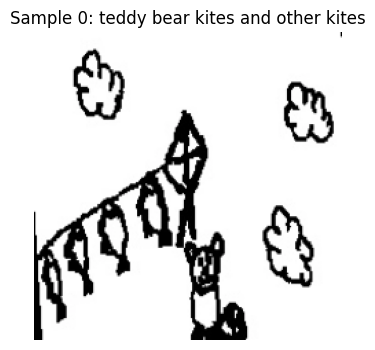

Sample 1 - Raw caption tensor: tensor([   1,  576, 2054,    2])
Sample 1 decoded caption: roadside sceneries


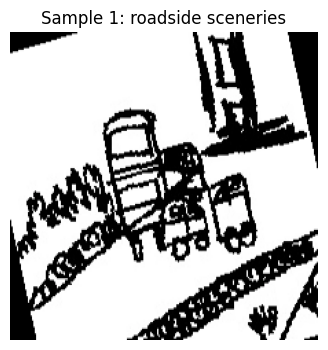

Sample 2 - Raw caption tensor: tensor([   1, 1371,  166,   27,  663,  526,  185,    2])
Sample 2 decoded caption: 3 giraffes are kissing each other


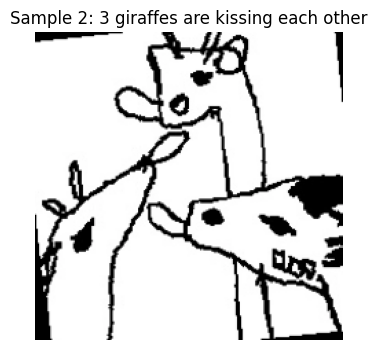

Sample 3 - Raw caption tensor: tensor([  1, 137,   2])
Sample 3 decoded caption: church


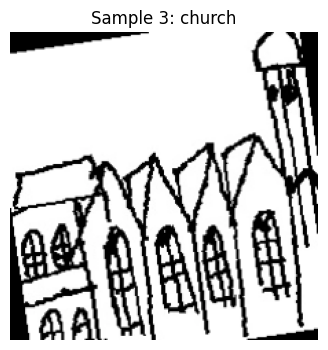

Sample 4 - Raw caption tensor: tensor([   1,    3, 1813, 1074,   99,    3, 1271,   22,    2])
Sample 4 decoded caption: a tonga infront of a palace tower


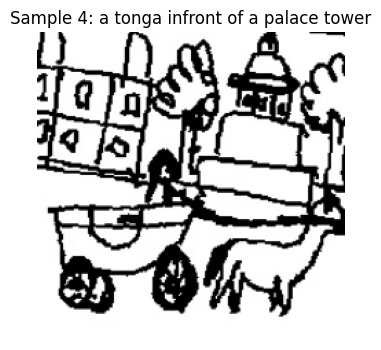

Sample 5 - Raw caption tensor: tensor([   1,  301,  297, 1108,   35,    3,  340,    2])
Sample 5 decoded caption: three elephants chilling by a river


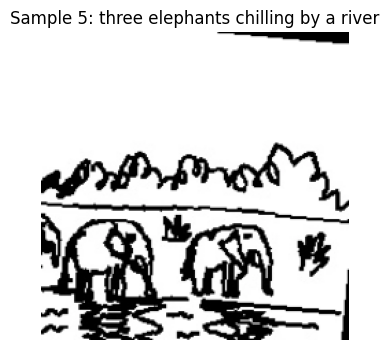

Sample 6 - Raw caption tensor: tensor([  1,   3, 819,  38,   3,  45,  19,  51,  17, 526, 185,   2])
Sample 6 decoded caption: a car and a cow is standing with each other


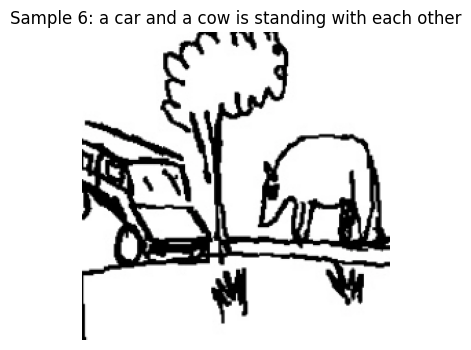

Sample 7 - Raw caption tensor: tensor([  1, 169, 160,   2])
Sample 7 decoded caption: boys playing


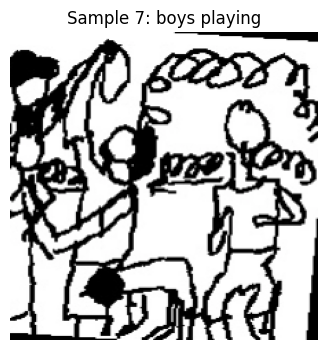

Sample 8 - Raw caption tensor: tensor([   1, 1766, 1767,   40,    2])
Sample 8 decoded caption: china airline plane


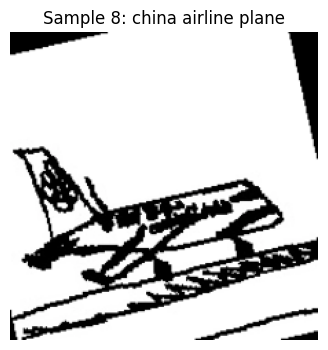

Sample 9 - Raw caption tensor: tensor([  1,   3,   4, 418,   3, 419,   2])
Sample 9 decoded caption: a giraffe licking a bark


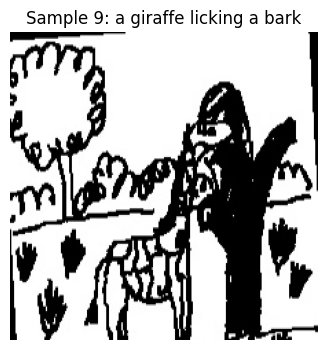

In [ ]:
import matplotlib.pyplot as plt
import torch

# Helper function to denormalize an image tensor
def denormalize(image_tensor):
    # ImageNet mean and std used in your transform
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return image_tensor * std + mean

# Iterate over the first 10 samples in the training dataset
for i in range(10):
    image, caption_tensor = train_dataset[i]
    print(f"Sample {i} - Raw caption tensor: {caption_tensor}")

    # Check if the tensor is empty
    if caption_tensor.numel() == 0:
        print(f"Sample {i} has an empty caption tensor.")
        continue

    # Check if the tensor consists only of the EOS token
    if caption_tensor.size(0) == 1 and caption_tensor.item() == vocab.word2idx[EOS_TOKEN]:
        print(f"Sample {i} contains only the EOS token.")
        continue

    # Convert the tensor to a list of token indices
    tokens = caption_tensor.tolist()

    # Optionally remove the <SOS> token if it is the first token
    if tokens[0] == vocab.word2idx[SOS_TOKEN]:
        tokens = tokens[1:]

    # Decode tokens until we hit the <EOS> token
    decoded_tokens = []
    for token in tokens:
        if token == vocab.word2idx[EOS_TOKEN]:
            break
        decoded_tokens.append(vocab.idx2word[token])

    decoded_caption = " ".join(decoded_tokens)
    print(f"Sample {i} decoded caption: {decoded_caption}")

    # Denormalize the image for visualization and convert to numpy array
    image_denorm = denormalize(image).clamp(0, 1)  # Clamp values to [0,1]
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()  # shape: (H, W, C)

    # Plot the image with the decoded caption as title
    plt.figure(figsize=(4, 4))
    plt.imshow(image_np)
    plt.title(f"Sample {i}: {decoded_caption}")
    plt.axis("off")
    plt.show()


Sample 0 - Raw caption tensor: tensor([   1, 1329,  327,   99,    3,  350,   76,    2])
Sample 0 decoded caption: night view of a city road


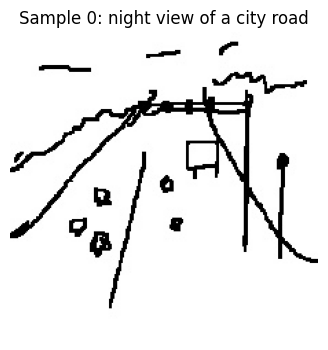

Sample 1 - Raw caption tensor: tensor([   1,    3,  104,  211,    3,  762,   19,  171,    3, 1282,  101,    2])
Sample 1 decoded caption: a man riding a motorcycle is seen a vast field.


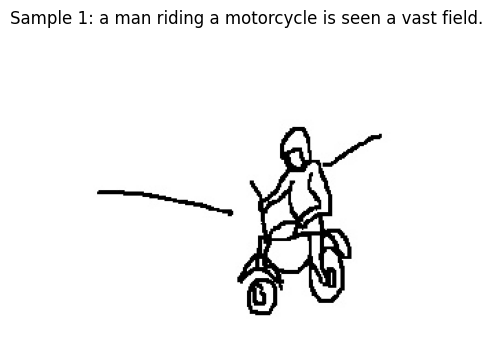

Sample 2 - Raw caption tensor: tensor([  1,  31, 135,  27, 136,  13,  14, 258, 101,   2])
Sample 2 decoded caption: two zebras are grazing in the green field.


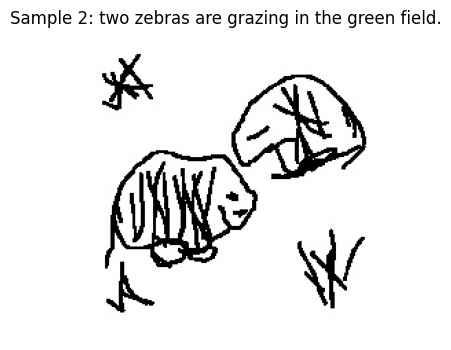

Sample 3 - Raw caption tensor: tensor([   1,    3,   21,   22,   19,  250,   51, 1576,    2])
Sample 3 decoded caption: a clock tower is there standing high.


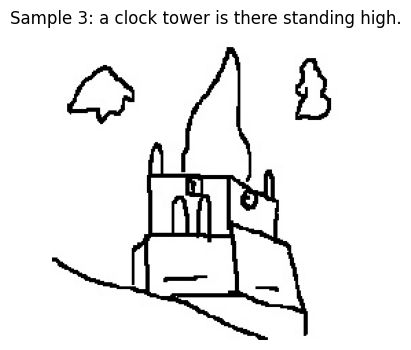

Sample 4 - Raw caption tensor: tensor([  1,  23,  88,  19,  13,  14, 248,   2])
Sample 4 decoded caption: an aeroplane is in the runway.


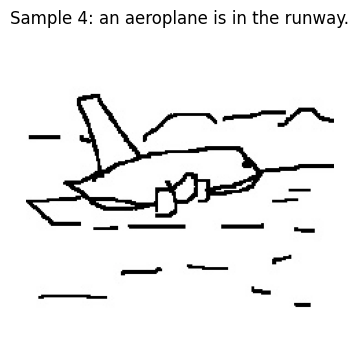

Sample 5 - Raw caption tensor: tensor([   1,   31,    9,   27,  211, 2512,    2])
Sample 5 decoded caption: two men are riding horse..


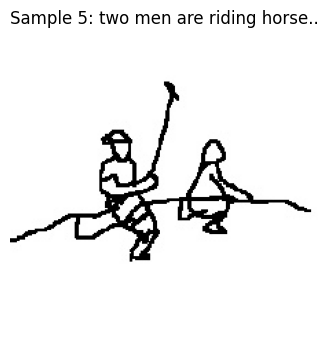

Sample 6 - Raw caption tensor: tensor([   1,    3,  424,   19,    5,   57, 1074,   99,    3,  832,  325,    2])
Sample 6 decoded caption: a goat is eating grass infront of a large house.


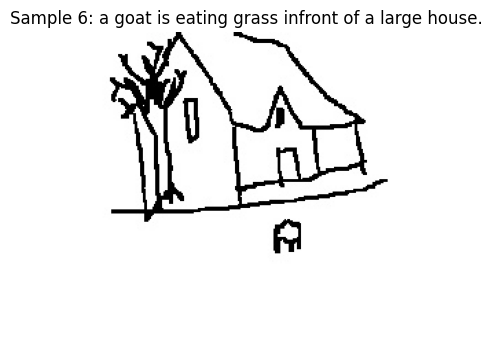

Sample 7 - Raw caption tensor: tensor([   1,    3, 2580,   99,    3,  929,   76,   99,    3,  162,    2])
Sample 7 decoded caption: a pictture of a busy road of a city.


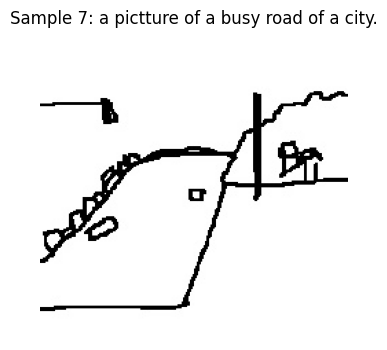

Sample 8 - Raw caption tensor: tensor([   1,    3, 1247,   99, 1441, 1442, 1443,   19,  171,   13,   14, 1444,
           2])
Sample 8 decoded caption: a landmark of mahatma gandhi plaza is seen in the picture.


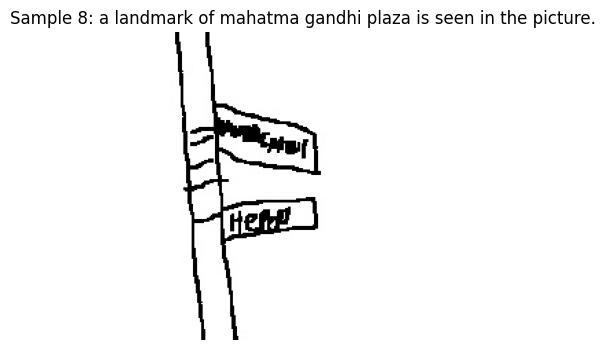

Sample 9 - Raw caption tensor: tensor([   1,    3,   21,  554,   35, 1863, 1824,   19,   13,  115,   46,    3,
         448,    2])
Sample 9 decoded caption: a clock made by colgate company is in construction near a river.


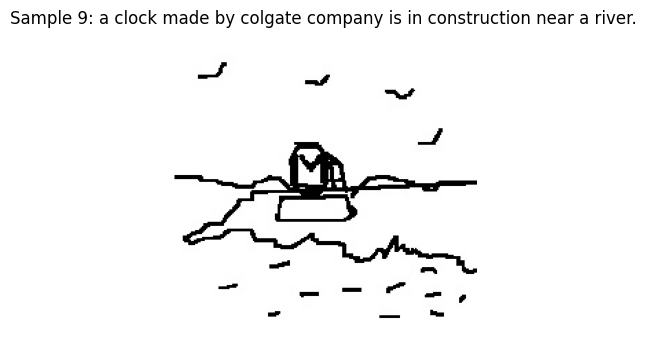

In [ ]:
import matplotlib.pyplot as plt
import torch

# Helper function to denormalize an image tensor
def denormalize(image_tensor):
    # ImageNet mean and std used in your transform
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return image_tensor * std + mean

# Iterate over the first 10 samples in the training dataset
for i in range(10):
    image, caption_tensor = test_dataset[i]
    print(f"Sample {i} - Raw caption tensor: {caption_tensor}")

    # Check if the tensor is empty
    if caption_tensor.numel() == 0:
        print(f"Sample {i} has an empty caption tensor.")
        continue

    # Check if the tensor consists only of the EOS token
    if caption_tensor.size(0) == 1 and caption_tensor.item() == vocab.word2idx[EOS_TOKEN]:
        print(f"Sample {i} contains only the EOS token.")
        continue

    # Convert the tensor to a list of token indices
    tokens = caption_tensor.tolist()

    # Optionally remove the <SOS> token if it is the first token
    if tokens[0] == vocab.word2idx[SOS_TOKEN]:
        tokens = tokens[1:]

    # Decode tokens until we hit the <EOS> token
    decoded_tokens = []
    for token in tokens:
        if token == vocab.word2idx[EOS_TOKEN]:
            break
        decoded_tokens.append(vocab.idx2word[token])

    decoded_caption = " ".join(decoded_tokens)
    print(f"Sample {i} decoded caption: {decoded_caption}")

    # Denormalize the image for visualization and convert to numpy array
    image_denorm = denormalize(image).clamp(0, 1)  # Clamp values to [0,1]
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()  # shape: (H, W, C)

    # Plot the image with the decoded caption as title
    plt.figure(figsize=(4, 4))
    plt.imshow(image_np)
    plt.title(f"Sample {i}: {decoded_caption}")
    plt.axis("off")
    plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Optimized EncoderCNN: Freeze all layers except layer4 and fc.
class EncoderCNN(nn.Module):
    def __init__(self, embed_dim):
        super(EncoderCNN, self).__init__()
        self.resnet = models.resnet50(pretrained=True)
        for name, param in self.resnet.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, embed_dim)

    def forward(self, images):
        features = self.resnet(images)
        return features

class DecoderRNN(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers=2, dropout=0.5):
        super(DecoderRNN, self).__init__()
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.num_layers = num_layers

        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.embed_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.init_h = nn.Linear(embed_dim, hidden_dim)
        self.init_c = nn.Linear(embed_dim, hidden_dim)

    def forward(self, features, captions, lengths):
        batch_size = features.size(0)
        h0 = self.init_h(features).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = self.init_c(features).unsqueeze(0).repeat(self.num_layers, 1, 1)

        # Shift captions: input (without last token) and target (without first token)
        inputs = captions[:, :-1]      # e.g. [<SOS>, w1, w2, ...]
        targets = captions[:, 1:]      # e.g. [w1, w2, ..., <EOS>]
        lengths = [l - 1 for l in lengths]

        embeddings = self.embed(inputs)
        embeddings = self.embed_dropout(embeddings)
        packed_embeds = nn.utils.rnn.pack_padded_sequence(embeddings, lengths,
                                                          batch_first=True, enforce_sorted=False)
        packed_outputs, _ = self.lstm(packed_embeds, (h0, c0))
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)
        outputs = self.fc_dropout(outputs)
        outputs = self.fc(outputs)
        return outputs, targets

    def generate_caption_beam(self, features, beam_size=3, max_length=30):
        """
        Generate caption using beam search.
        """
        self.eval()
        device = features.device
        # Initialize LSTM states
        h = self.init_h(features).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c = self.init_c(features).unsqueeze(0).repeat(self.num_layers, 1, 1)

        # Each beam: (tokens, cumulative log-probability, hidden state, cell state)
        beams = [([vocab.word2idx[SOS_TOKEN]], 0.0, h, c)]
        completed_beams = []

        for _ in range(max_length):
            new_beams = []
            for tokens, score, h_state, c_state in beams:
                # If the beam already ended, carry it forward
                if tokens[-1] == vocab.word2idx[EOS_TOKEN]:
                    completed_beams.append((tokens, score))
                    continue
                inp = torch.tensor([[tokens[-1]]], device=device)
                embed = self.embed(inp)
                embed = self.embed_dropout(embed)
                out, (h_new, c_new) = self.lstm(embed, (h_state, c_state))
                out = self.fc_dropout(out.squeeze(1))
                out = self.fc(out)
                log_probs = torch.log_softmax(out, dim=-1)

                # Get top beam_size candidates
                topk_log_probs, topk_indices = log_probs.topk(beam_size)
                for log_prob, idx in zip(topk_log_probs[0], topk_indices[0]):
                    new_tokens = tokens + [idx.item()]
                    new_score = score + log_prob.item()
                    new_beams.append((new_tokens, new_score, h_new, c_new))

            # Sort and select the best beams
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]
            if not beams:
                break

        # If no beam finished with <EOS>, take the current best beams
        if not completed_beams:
            completed_beams = beams

        # Choose the beam with the highest score
        best_tokens, _ = sorted(completed_beams, key=lambda x: x[1], reverse=True)[0]
        # Convert token indices to words (remove <SOS> and <EOS>)
        caption_words = [vocab.idx2word[idx] for idx in best_tokens
                         if idx not in (vocab.word2idx[SOS_TOKEN], vocab.word2idx[EOS_TOKEN])]
        return " ".join(caption_words)


class CaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super(CaptioningModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions, lengths):
        features = self.encoder(images)
        outputs = self.decoder(features, captions, lengths)
        return outputs

# Example initialization of the optimized model components
embed_dim = 256   # Can be tuned
hidden_dim = 256  # Can be tuned
vocab_size = len(vocab)

encoder = EncoderCNN(embed_dim=embed_dim)
decoder = DecoderRNN(embed_dim=embed_dim, hidden_dim=hidden_dim, vocab_size=vocab_size, num_layers=2, dropout=0.5)
model = CaptioningModel(encoder, decoder).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


In [ ]:
!pip install evaluate nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.

In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a9e84603a5992018169dfea7d2259b5058fa47c7ff014fa56360250e72a103eb
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [ ]:

criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx[PAD_TOKEN])

In [ ]:
# DO NOT RUN - ONLY NEEDS FOR RETRAIN.
#

import math
from torch import optim
import evaluate
import nltk
nltk.download('wordnet', quiet=True)  # for METEOR if needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx[PAD_TOKEN])
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
# Learning rate scheduler to reduce LR on plateau (helps prevent overfitting)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1,
                                                 patience=3, verbose=True)

# Metrics evaluators
bleu_evaluator = evaluate.load("bleu")
meteor_evaluator = evaluate.load("meteor")
rouge_evaluator = evaluate.load("rouge")
try:
    from pycocoevalcap.cider.cider import Cider
    cider_evaluator = Cider()
except ImportError:
    cider_evaluator = None

def evaluate_metrics(predictions, references):
    """
    Compute BLEU, METEOR, ROUGE-L, and CIDEr for a list of prediction and reference strings.
    Both predictions and references should be lists of full caption strings.
    """
    results = {}
    bleu_scores = bleu_evaluator.compute(predictions=predictions,
                                         references=references)
    results['BLEU'] = bleu_scores["bleu"]

    meteor_score = meteor_evaluator.compute(predictions=predictions, references=references)
    results['METEOR'] = meteor_score["meteor"]

    rouge_score = rouge_evaluator.compute(predictions=predictions, references=references)
    results['ROUGE-L'] = rouge_score["rougeL"].mid.fmeasure if hasattr(rouge_score["rougeL"], 'mid') else rouge_score["rougeL"]

    if cider_evaluator:
        pred_dicts = [{"image_id": i, "caption": pred} for i, pred in enumerate(predictions)]
        ref_dicts = {i: [ref] for i, ref in enumerate(references)}
        cider_score, _ = cider_evaluator.compute_score(ref_dicts, pred_dicts)
        results['CIDEr'] = cider_score
    else:
        results['CIDEr'] = None
    return results

# Training loop
num_epochs = 20
best_cider = -math.inf
best_model_path = "best_model.pth"

for epoch in range(1, num_epochs+1):
    model.train()
    total_loss = 0.0
    total_steps = 0
    print(f"Epoch {epoch}/{num_epochs} - Training...")
    for images, captions, lengths in train_loader:
        images = images.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()

        # Unpack the tuple returned by the model
        outputs, targets = model(images, captions, lengths)

        batch_size = outputs.size(0)
        max_len = outputs.size(1)
        outputs = outputs.reshape(batch_size * max_len, -1)
        targets = targets.reshape(batch_size * max_len)


        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_steps += 1
    avg_loss = total_loss / total_steps
    print(f"  Training Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)

    # Validation
    model.eval()
    val_predictions = []
    val_references = []
    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images = images.to(device)
            for i in range(images.size(0)):
                feat = model.encoder(images[i].unsqueeze(0))
                pred_caption = model.decoder.generate_caption_beam(feat, max_length=30, beam_size=1)
                # Process reference caption
                ref_caption_idx = captions[i].tolist()
                ref_words = []
                for token in ref_caption_idx:
                    if token == vocab.word2idx[EOS_TOKEN] or token == vocab.word2idx[PAD_TOKEN]:
                        break
                    if token != vocab.word2idx[SOS_TOKEN]:
                        ref_words.append(vocab.idx2word[token])
                ref_caption = " ".join(ref_words)
                if not pred_caption.strip():
                    pred_caption = "a sketch"
                if not ref_caption.strip():
                    ref_caption = "a sketch"
                val_predictions.append(pred_caption)
                val_references.append(ref_caption)

    if len(val_predictions) == 0 or len(val_references) == 0:
        print("No predictions or references generated, skipping metric evaluation.")
    else:
        val_scores = evaluate_metrics(val_predictions, val_references)
        cider_str = f"{val_scores['CIDEr']:.4f}" if val_scores['CIDEr'] is not None else "0.0000"
        print(f"  Validation Metrics: BLEU={val_scores['BLEU']:.4f}, METEOR={val_scores['METEOR']:.4f}, "
              f"ROUGE-L={val_scores['ROUGE-L']:.4f}, CIDEr={cider_str}")

    # Save best model based on CIDEr or fallback to BLEU
    if val_scores['CIDEr'] is not None and val_scores['CIDEr'] > best_cider:
        best_cider = val_scores['CIDEr']
        torch.save(model.state_dict(), best_model_path)
        print("  New best model saved.")
    elif val_scores['CIDEr'] is None and val_scores['BLEU'] > best_cider:
        best_cider = val_scores['BLEU']
        torch.save(model.state_dict(), best_model_path)
        print("  New best model (by BLEU) saved.")


Average Test Loss: 3.1115


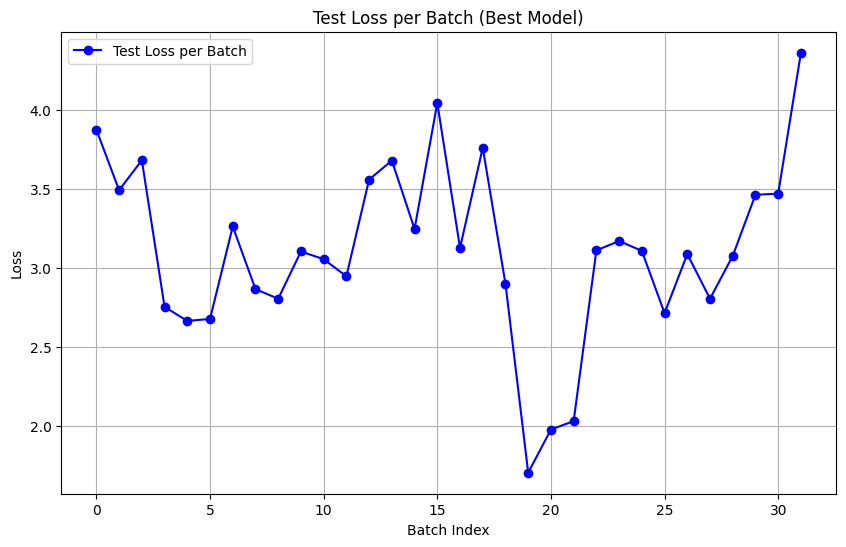

In [ ]:
import torch
import matplotlib.pyplot as plt

# Set device and load the saved best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# List to store loss values for each test batch
test_losses = []

# Evaluate on the test set using the best model
with torch.no_grad():
    for images, captions, lengths in test_loader:
        images = images.to(device)
        captions = captions.to(device)

        # Unpack the tuple returned by the model
        outputs, targets = model(images, captions, lengths)

        batch_size = outputs.size(0)
        max_len = outputs.size(1)
        outputs = outputs.reshape(batch_size * max_len, -1)
        targets = targets.reshape(batch_size * max_len)

        # Compute loss for this batch
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

# Plot test loss per batch using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(range(len(test_losses)), test_losses, marker='o', linestyle='-', color='blue', label="Test Loss per Batch")
plt.xlabel("Batch Index")
plt.ylabel("Loss")
plt.title("Test Loss per Batch (Best Model)")
plt.legend()
plt.grid(True)


# Optionally, print the average test loss
avg_test_loss = sum(test_losses) / len(test_losses)
print(f"Average Test Loss: {avg_test_loss:.4f}")

plt.savefig("testloss_per_batch.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
import evaluate
# Metrics evaluators
bleu_evaluator = evaluate.load("bleu")
meteor_evaluator = evaluate.load("meteor")
rouge_evaluator = evaluate.load("rouge")
try:
    from pycocoevalcap.cider.cider import Cider
    cider_evaluator = Cider()
except ImportError:
    cider_evaluator = None

def evaluate_metrics(predictions, references):
    """
    Compute BLEU, METEOR, ROUGE-L, and CIDEr for a list of prediction and reference strings.
    Both predictions and references should be lists of full caption strings.
    """
    results = {}
    bleu_scores = bleu_evaluator.compute(predictions=predictions,
                                         references=references)
    results['BLEU'] = bleu_scores["bleu"]

    meteor_score = meteor_evaluator.compute(predictions=predictions, references=references)
    results['METEOR'] = meteor_score["meteor"]

    rouge_score = rouge_evaluator.compute(predictions=predictions, references=references)
    results['ROUGE-L'] = rouge_score["rougeL"].mid.fmeasure if hasattr(rouge_score["rougeL"], 'mid') else rouge_score["rougeL"]

    if cider_evaluator:
        pred_dicts = [{"image_id": i, "caption": pred} for i, pred in enumerate(predictions)]
        ref_dicts = {i: [ref] for i, ref in enumerate(references)}
        cider_score, _ = cider_evaluator.compute_score(ref_dicts, pred_dicts)
        results['CIDEr'] = cider_score
    else:
        results['CIDEr'] = None
    return results


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
import torch
import matplotlib.pyplot as plt

# Ensure your model class definitions, vocab, etc. are already imported or defined here.

# 1. Load the best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# 2. Prepare lists to store per-batch metrics
batch_meteor_list = []
batch_rouge_list = []
batch_bleu_list = []

# 3. Evaluate on the test set, computing METEOR/ROUGE per batch
with torch.no_grad():
    for batch_idx, (images, captions, lengths) in enumerate(test_loader):
        images = images.to(device)

        # Collect predictions and references for this batch
        batch_predictions = []
        batch_references = []

        for i in range(images.size(0)):
            # Generate a caption for each image in the batch
            feat = model.encoder(images[i].unsqueeze(0))  # shape: (1, embed_dim)
            pred_caption = model.decoder.generate_caption_beam(feat, max_length=30, beam_size=1)

            # Process reference caption
            ref_caption_idx = captions[i].tolist()
            ref_words = []
            for token in ref_caption_idx:
                if token == vocab.word2idx[EOS_TOKEN] or token == vocab.word2idx[PAD_TOKEN]:
                    break
                if token != vocab.word2idx[SOS_TOKEN]:
                    ref_words.append(vocab.idx2word[token])
            ref_caption = " ".join(ref_words)

            # Handle empty predictions/references
            if not pred_caption.strip():
                pred_caption = "a sketch"
            if not ref_caption.strip():
                ref_caption = "a sketch"

            batch_predictions.append(pred_caption)
            batch_references.append(ref_caption)

        # Now compute METEOR and ROUGE-L for this batch
        batch_scores = evaluate_metrics(batch_predictions, batch_references)
        meteor_val = batch_scores["METEOR"]
        rouge_val = batch_scores["ROUGE-L"]
        bleu_val = batch_scores["BLEU"]

        batch_meteor_list.append(meteor_val)
        batch_rouge_list.append(rouge_val)
        batch_bleu_list.append(bleu_val)

        print(f"Batch {batch_idx}: METEOR={meteor_val:.4f}, ROUGE-L={rouge_val:.4f}, BLEU={bleu_val:.4f}")

print("Done evaluating batch-by-batch metrics.")


Batch 0: METEOR=0.2368, ROUGE-L=0.3367, BLEU=0.0968
Batch 1: METEOR=0.2770, ROUGE-L=0.3626, BLEU=0.0850
Batch 2: METEOR=0.2199, ROUGE-L=0.2907, BLEU=0.0425
Batch 3: METEOR=0.2599, ROUGE-L=0.3361, BLEU=0.0546
Batch 4: METEOR=0.2398, ROUGE-L=0.3201, BLEU=0.0738
Batch 5: METEOR=0.2882, ROUGE-L=0.3552, BLEU=0.1025
Batch 6: METEOR=0.2117, ROUGE-L=0.3124, BLEU=0.0000
Batch 7: METEOR=0.3264, ROUGE-L=0.4083, BLEU=0.0942
Batch 8: METEOR=0.2108, ROUGE-L=0.3001, BLEU=0.0000
Batch 9: METEOR=0.2965, ROUGE-L=0.3377, BLEU=0.1234
Batch 10: METEOR=0.2709, ROUGE-L=0.3385, BLEU=0.1208
Batch 11: METEOR=0.2744, ROUGE-L=0.3186, BLEU=0.0990
Batch 12: METEOR=0.2486, ROUGE-L=0.3245, BLEU=0.0819
Batch 13: METEOR=0.2585, ROUGE-L=0.3269, BLEU=0.0868
Batch 14: METEOR=0.2656, ROUGE-L=0.3341, BLEU=0.0793
Batch 15: METEOR=0.2684, ROUGE-L=0.3428, BLEU=0.0584
Batch 16: METEOR=0.2460, ROUGE-L=0.3357, BLEU=0.0000
Batch 17: METEOR=0.2303, ROUGE-L=0.3296, BLEU=0.0000
Batch 18: METEOR=0.2870, ROUGE-L=0.3512, BLEU=0.1214
Bat

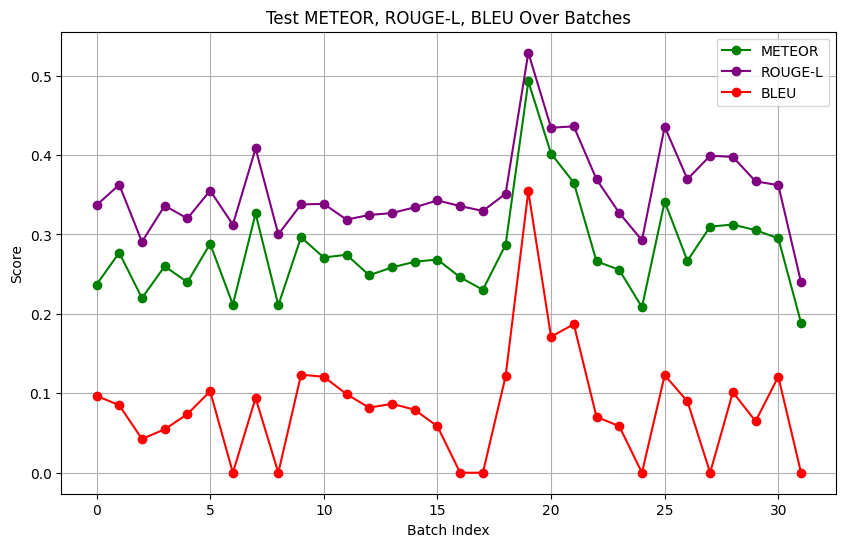

In [ ]:
import numpy as np

# 4. Plot METEOR and ROUGE-L over batches
batch_indices = np.arange(len(batch_meteor_list))

plt.figure(figsize=(10, 6))
plt.plot(batch_indices, batch_meteor_list, marker='o', color='green', label="METEOR")
plt.plot(batch_indices, batch_rouge_list, marker='o', color='purple', label="ROUGE-L")
plt.plot(batch_indices, batch_bleu_list, marker='o', color='red', label="BLEU")
plt.xlabel("Batch Index")
plt.ylabel("Score")
plt.title("Test METEOR, ROUGE-L, BLEU Over Batches")
plt.grid(True)
plt.legend()

plt.savefig("test_over_batches.pdf", format="pdf", bbox_inches="tight")
plt.show()



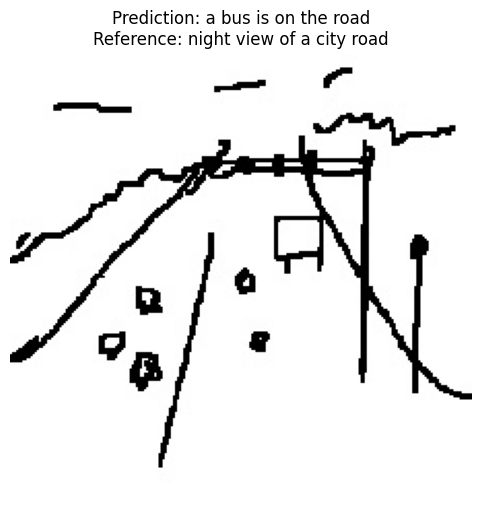

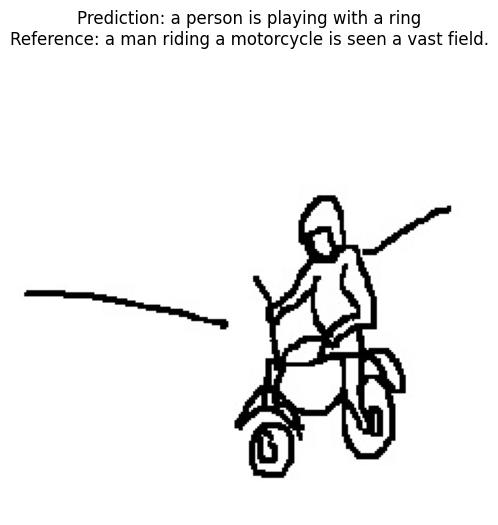

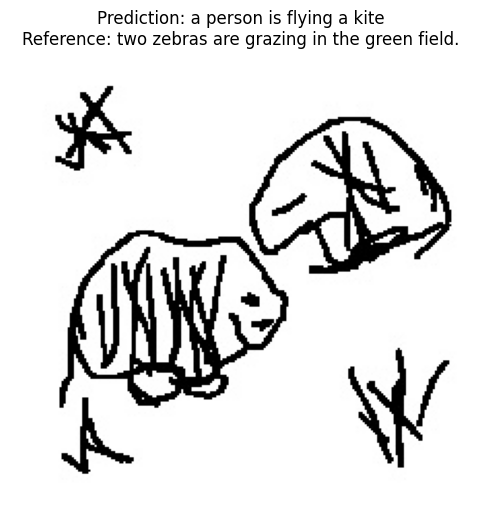

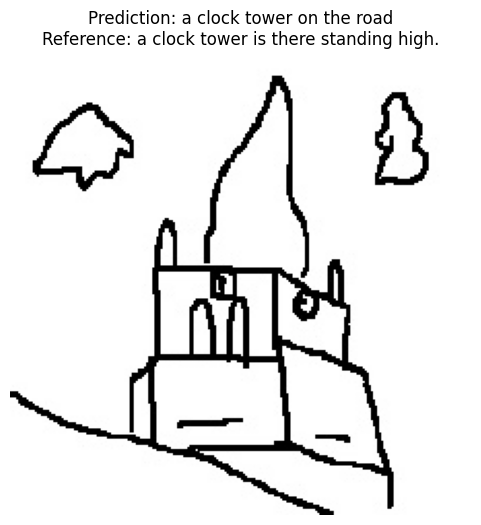

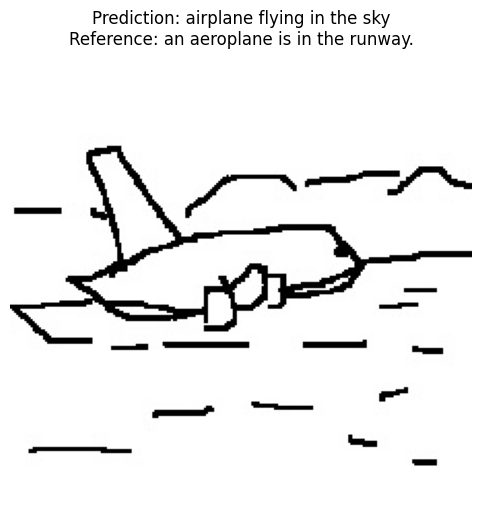

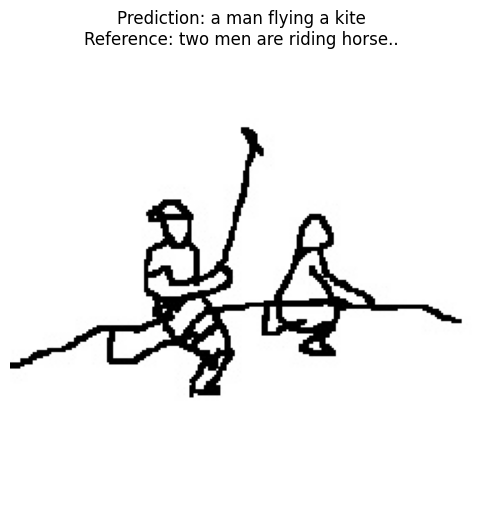

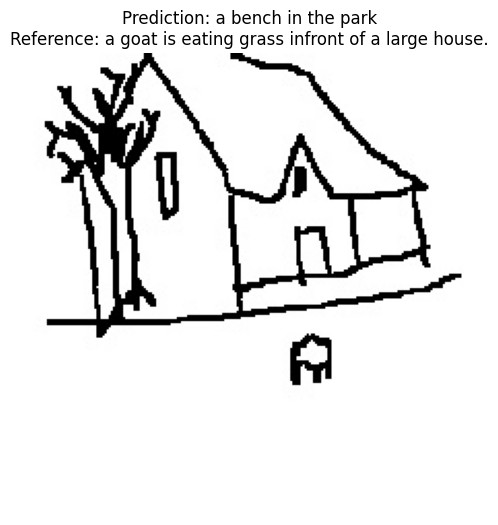

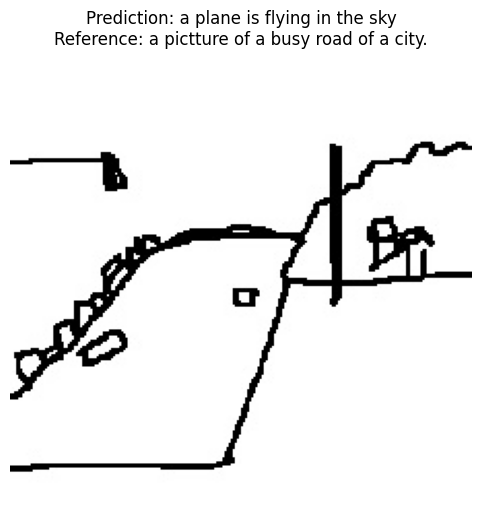

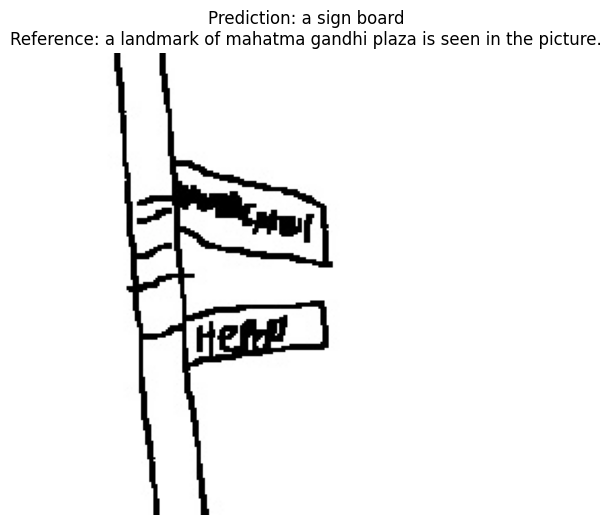

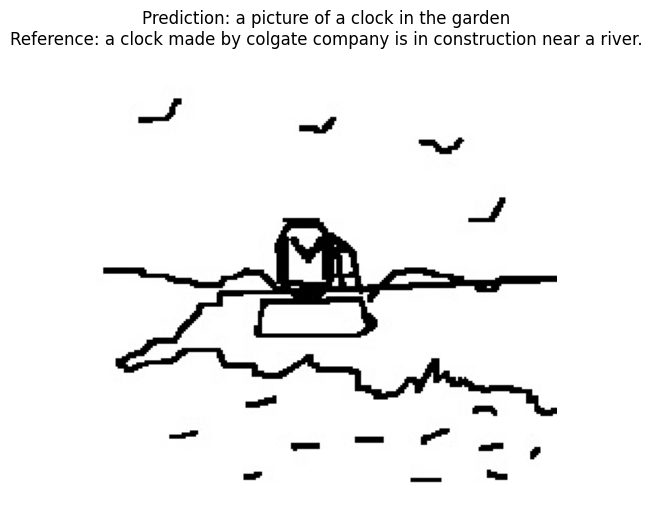

In [ ]:
import matplotlib.pyplot as plt
import torch

# Helper function to denormalize images for visualization.
def denormalize(image_tensor):
    device = image_tensor.device
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
    return image_tensor * std + mean

# Set model to evaluation mode
model.eval()

# Number of test samples to display
num_samples_to_display = 10
displayed = 0

with torch.no_grad():
    for images, captions, lengths in test_loader:
        images = images.to(device)
        for i in range(images.size(0)):
            # Generate prediction for a single image
            feat = model.encoder(images[i].unsqueeze(0))
            pred_caption = model.decoder.generate_caption_beam(feat, max_length=30, beam_size=1)

            # Process reference caption: decode the tensor into a human-readable string.
            ref_caption_idx = captions[i].tolist()
            ref_words = []
            for token in ref_caption_idx:
                if token == vocab.word2idx[EOS_TOKEN] or token == vocab.word2idx[PAD_TOKEN]:
                    break
                if token != vocab.word2idx[SOS_TOKEN]:
                    ref_words.append(vocab.idx2word[token])
            ref_caption = " ".join(ref_words)

            # Denormalize image for display
            image_denorm = denormalize(images[i]).clamp(0, 1)
            image_np = image_denorm.permute(1, 2, 0).cpu().numpy()

            # Display the image with both predicted and reference captions as title
            plt.figure(figsize=(6, 6))
            plt.imshow(image_np)
            plt.title(f"Prediction: {pred_caption}\nReference: {ref_caption}")
            plt.axis("off")
            plt.show()

            displayed += 1
            if displayed >= num_samples_to_display:
                break
        if displayed >= num_samples_to_display:
            break


In [ ]:
import torch
from torchvision import transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = YourModelClass()
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# Define the image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Adjust size according to your model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    with torch.no_grad():
        caption = model.generate_caption(image)  # Implement this in your model

    return caption

if __name__ == "__main__":
    image_path = input("Enter the path to your image: ")
    caption = predict_caption(image_path)
    print("Predicted Caption:", caption)

BLIP-1 Code

In [ ]:
!pip install transformers
!pip install accelerate
!pip install torch torchvision

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch

# Load a pretrained model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = model_blip.to("cuda" if torch.cuda.is_available() else "cpu")

def blip_generate_caption(image_pil):
    prompt = "Describe this drawing."
    device = "cuda" if torch.cuda.is_available() else "cpu"
    inputs = processor(image_pil, prompt, return_tensors="pt").to(device)

    out = model_blip.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
import torch
import evaluate
from tqdm import tqdm
from torchvision import transforms
from PIL import Image

# Already loaded:
# model = CaptioningModel(...)
# model.load_state_dict(torch.load('best_model.pth'))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CaptioningModel(encoder, decoder).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model = model.to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# Evaluation metrics
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")
rouge = evaluate.load("rouge")

your_predictions = []
blip_predictions = []
references = []


# Adjust transform for sending image to Mistral (if needed)
blip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

# Go through test_loader
for batch_images, batch_captions, batch_lengths in tqdm(test_loader):

    batch_images = batch_images.to(device)

    for i in range(batch_images.size(0)):
        image_tensor = batch_images[i].unsqueeze(0)

        # ======= (1) Your model's caption =======
        with torch.no_grad():
            features = model.encoder(image_tensor)
            pred_caption = model.decoder.generate_caption_beam(features, max_length=30, beam_size=3)

        your_predictions.append(pred_caption)

        # ======= (2) blip caption =======
        # In your dataset class, you have access to the original file paths
        # So alternatively, gather test file paths separately if needed

        img_np = transforms.ToPILImage()(batch_images[i].cpu().squeeze(0))
        blip_caption = blip_generate_caption(img_np)
        blip_predictions.append(blip_caption)

        # ======= (3) Reference ground truth =======
        gt_tokens = batch_captions[i].tolist()
        gt_words = []
        for token in gt_tokens:
            if token == vocab.word2idx[EOS_TOKEN] or token == vocab.word2idx[PAD_TOKEN]:
                break
            if token != vocab.word2idx[SOS_TOKEN]:
                gt_words.append(vocab.idx2word[token])
        ground_truth = " ".join(gt_words)
        references.append(ground_truth)

# ==== Compute Metrics ====

# Your model
your_bleu = bleu.compute(predictions=your_predictions, references=references)["bleu"]
your_meteor = meteor.compute(predictions=your_predictions, references=references)["meteor"]
your_rouge = rouge.compute(predictions=your_predictions, references=references)["rougeL"]

# BLIP zero-shot
blip_bleu = bleu.compute(predictions=blip_predictions, references=references)["bleu"]
blip_meteor = meteor.compute(predictions=blip_predictions, references=references)["meteor"]
blip_rouge = rouge.compute(predictions=blip_predictions, references=references)["rougeL"]

# ==== Print results ====
print("===== Your Model =====")
print(f"BLEU: {your_bleu:.4f}, METEOR: {your_meteor:.4f}, ROUGE-L: {your_rouge:.4f}")

print("===== BLIP-1 Zero-Shot =====")
print(f"BLEU: {blip_bleu:.4f}, METEOR: {blip_meteor:.4f}, ROUGE-L: {blip_rouge:.4f}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!

100%|██████████| 32/32 [02:29<00:00,  4.68s/it]


===== Your Model =====
BLEU: 0.1013, METEOR: 0.2728, ROUGE-L: 0.3527
===== BLIP-1 Zero-Shot =====
BLEU: 0.0038, METEOR: 0.0289, ROUGE-L: 0.0204


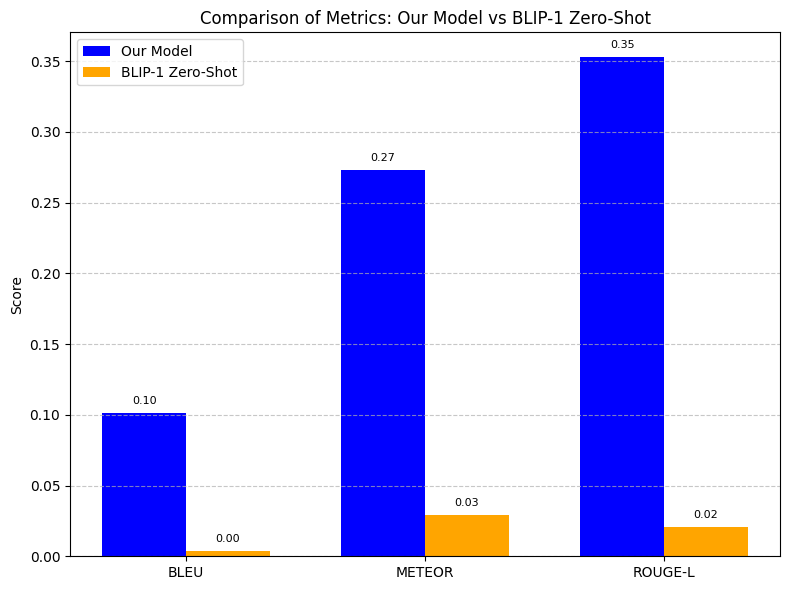

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ["BLEU", "METEOR", "ROUGE-L"]
your_scores = [your_bleu, your_meteor, your_rouge]
blip_scores = [blip_bleu, blip_meteor, blip_rouge]

x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, your_scores, width, label='Our Model', color='blue')
rects2 = ax.bar(x + width/2, blip_scores, width, label='BLIP-1 Zero-Shot', color='orange')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Comparison of Metrics: Our Model vs BLIP-1 Zero-Shot')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
def autolabel(rects):
    """Attach a text label above each bar."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# Save to PDF for LaTeX use
plt.savefig('comparison_metrics.pdf')  # << IMPORTANT for your Overleaf
plt.show()


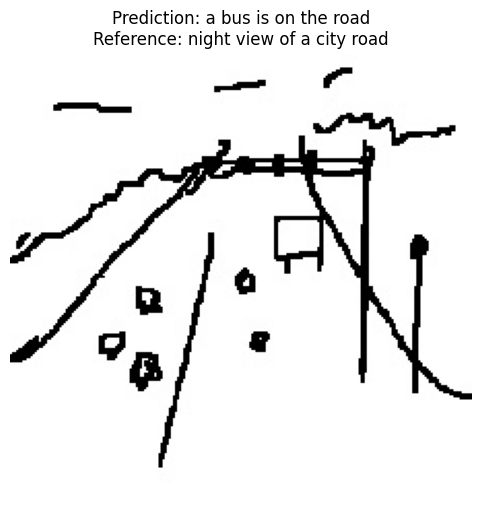

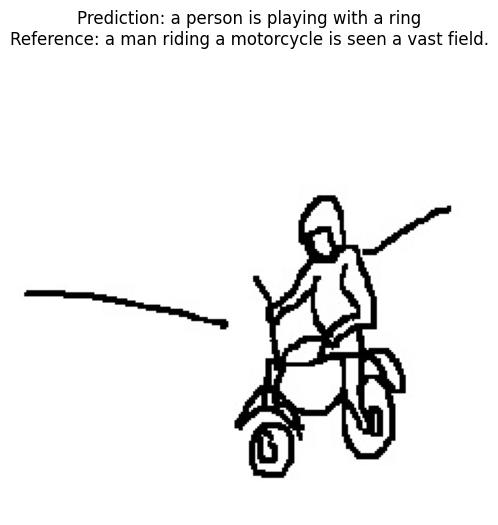

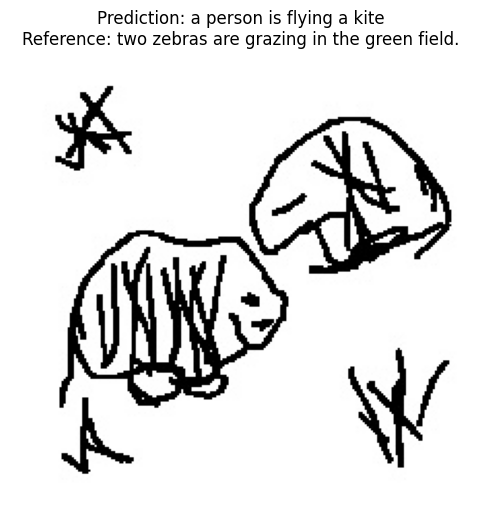

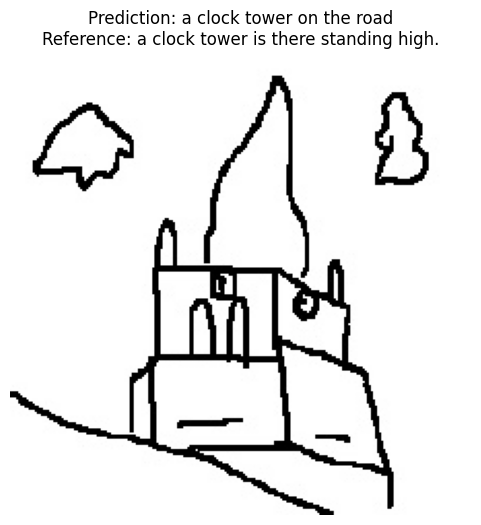

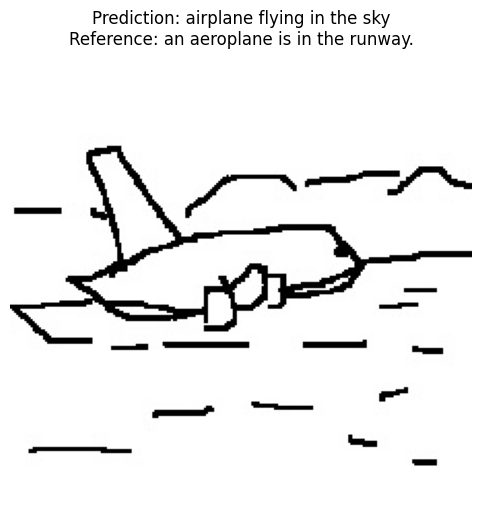

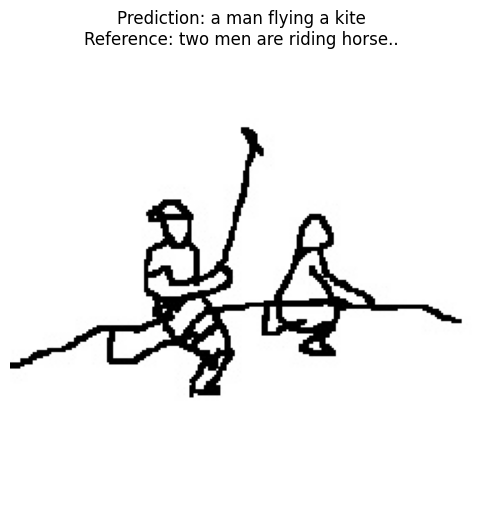

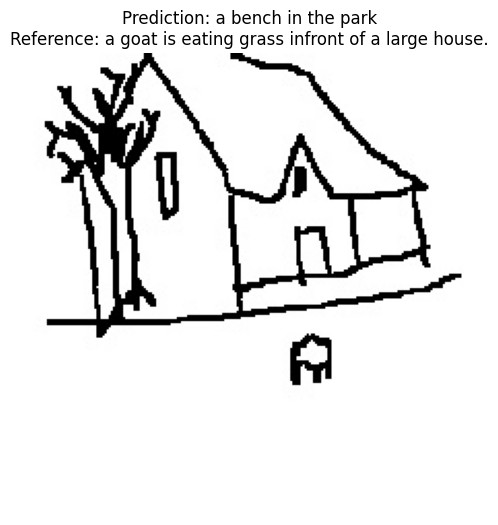

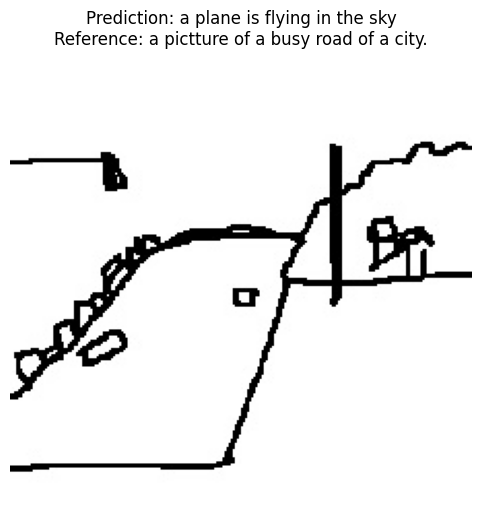

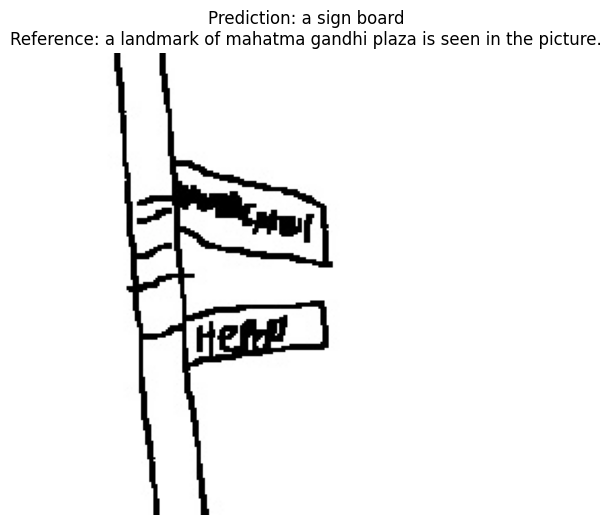

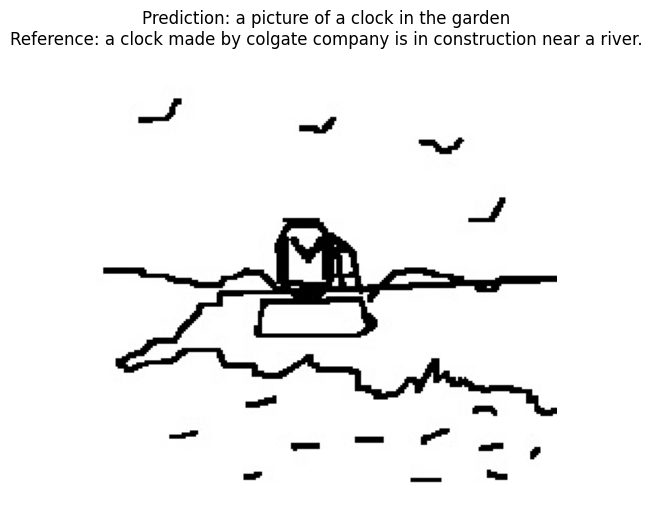

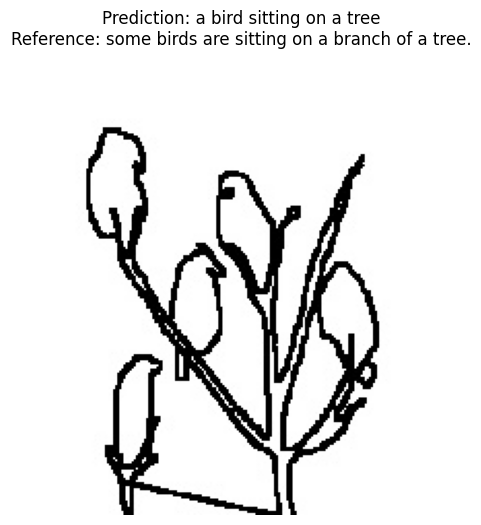

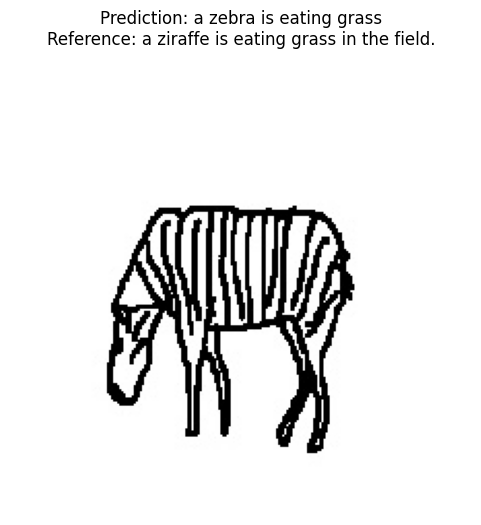

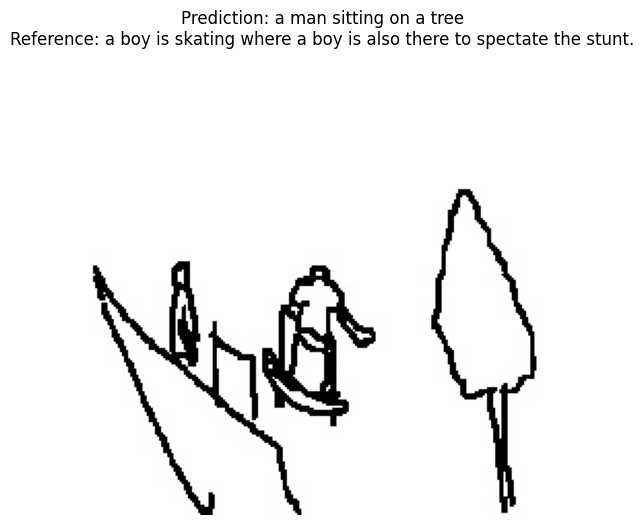

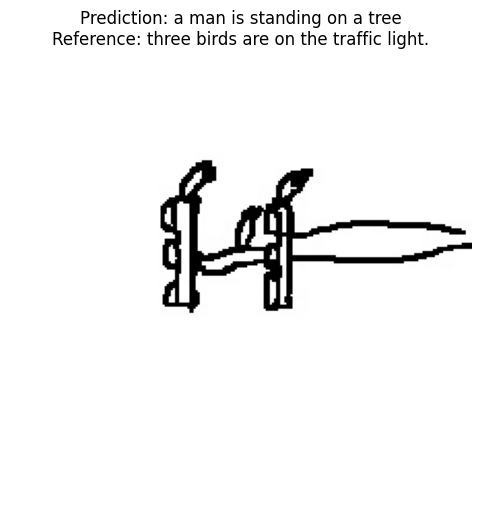

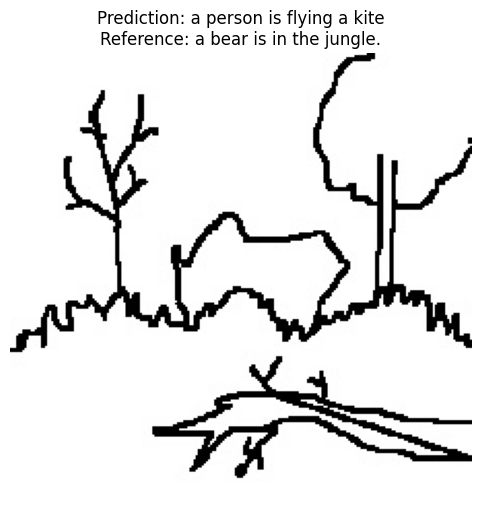

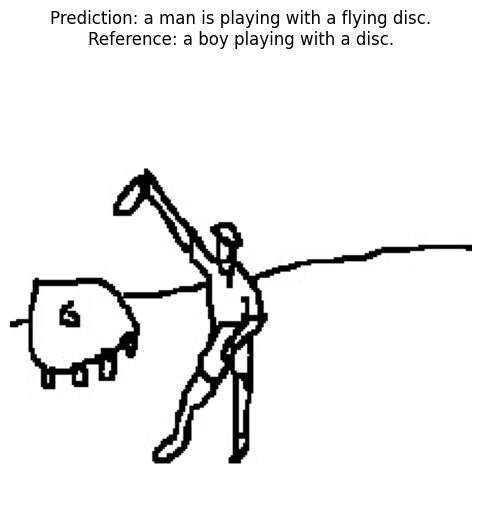

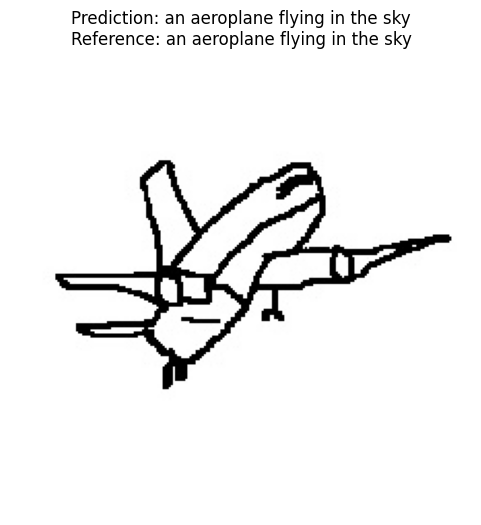

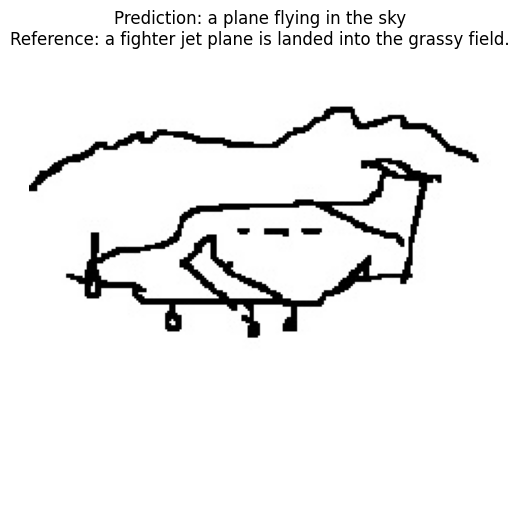

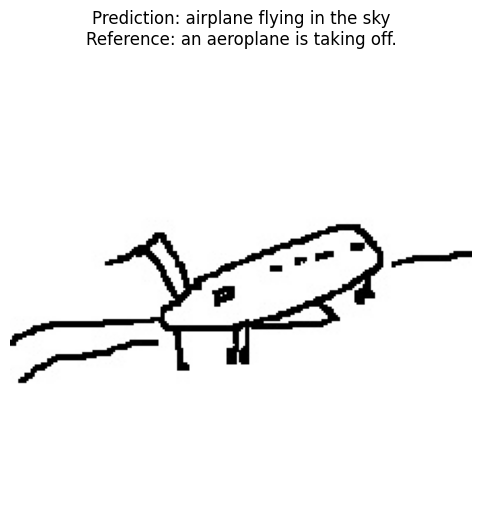

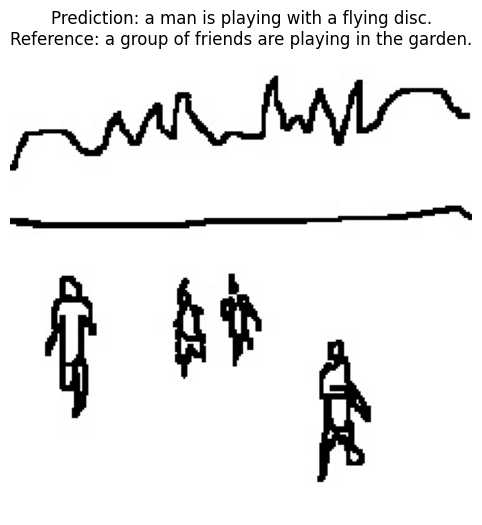

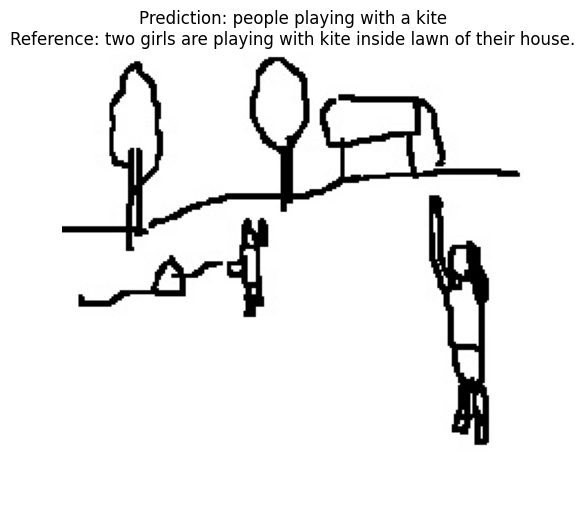

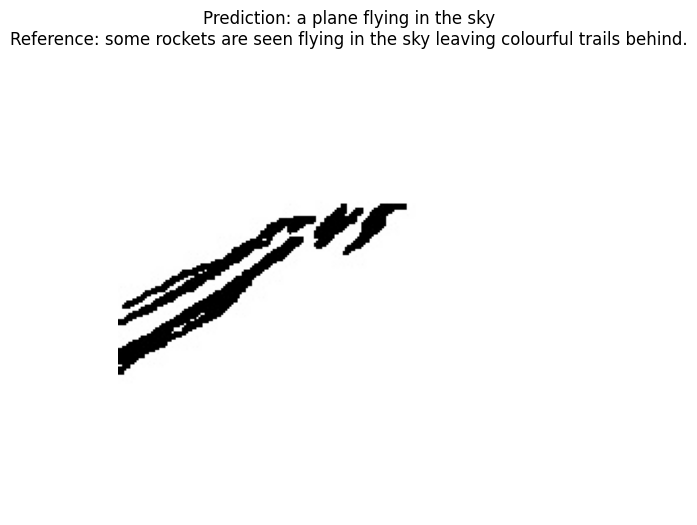

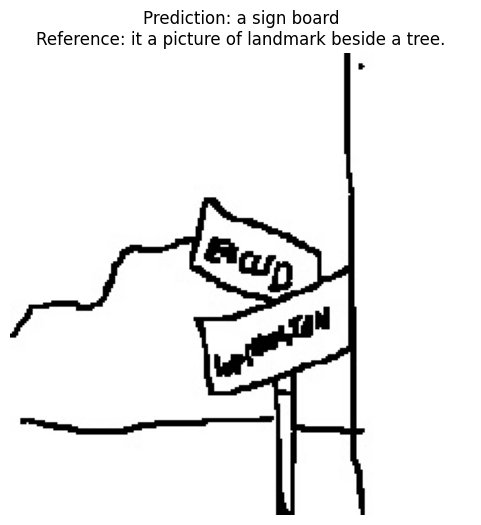

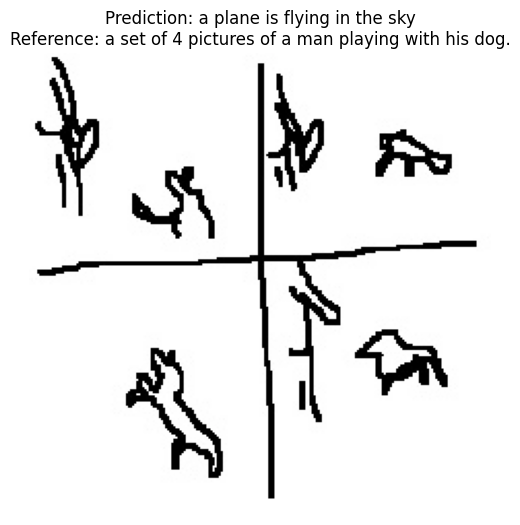

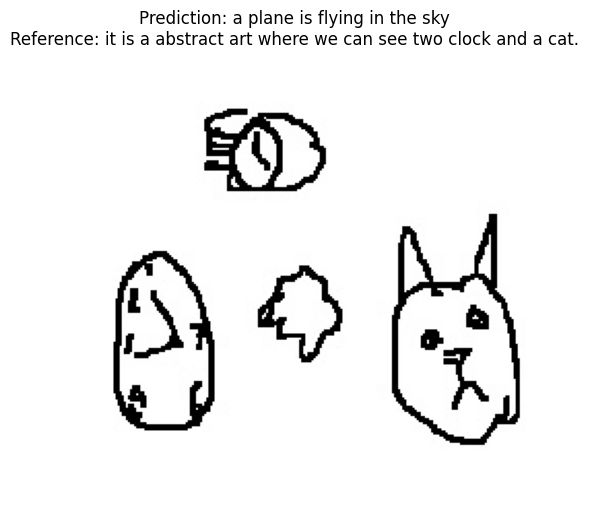

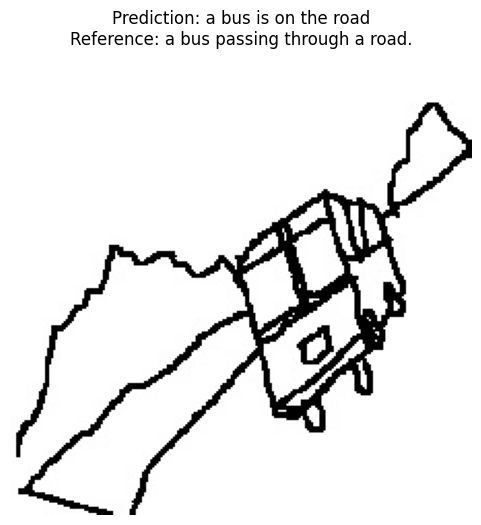

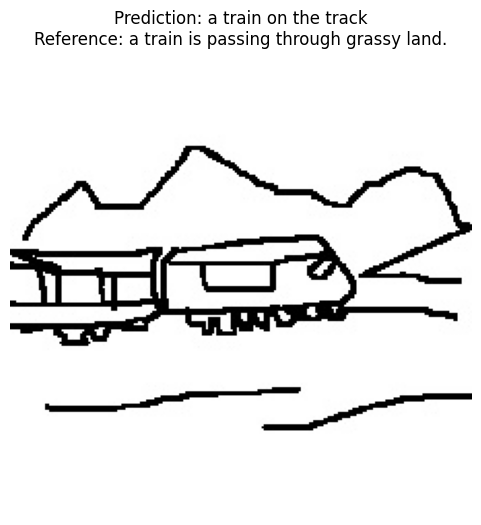

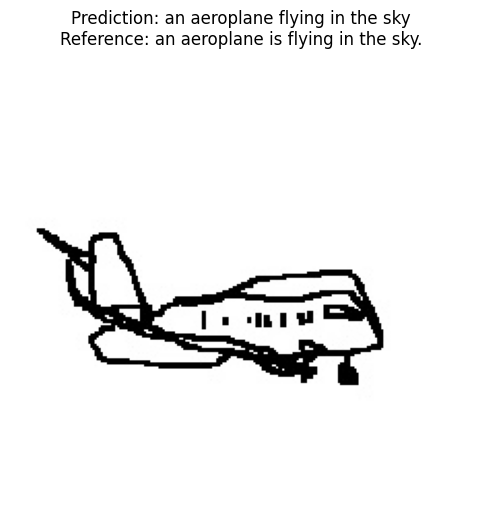

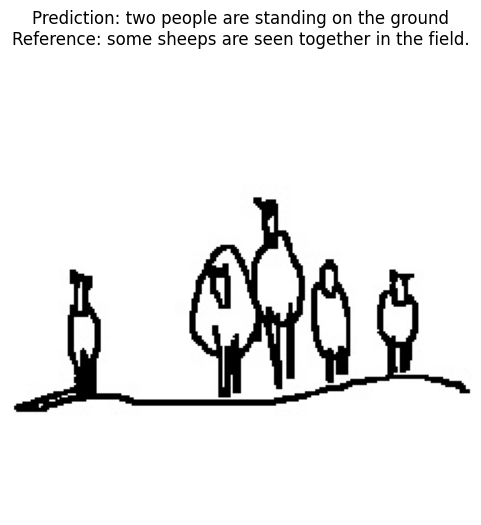

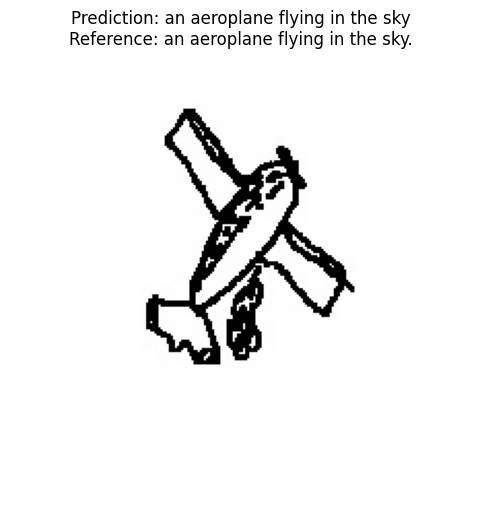

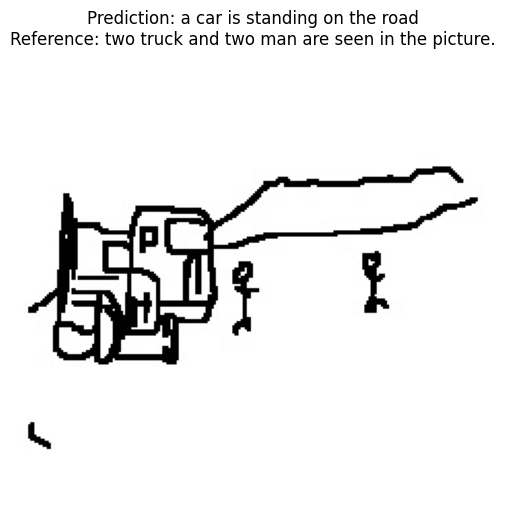

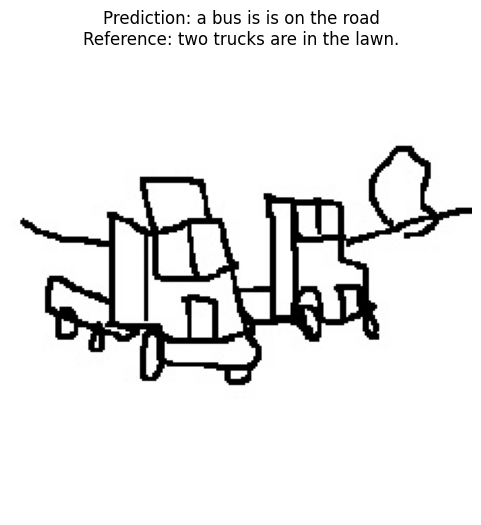

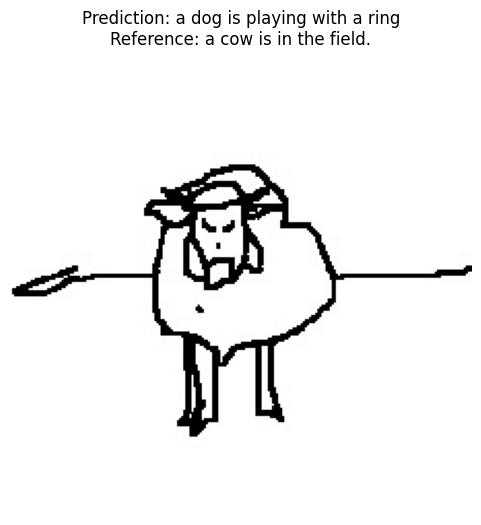

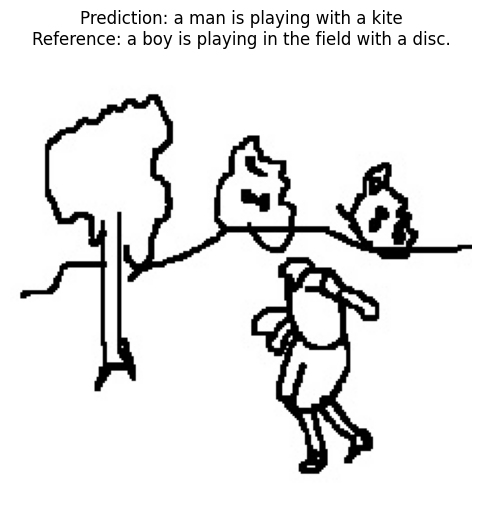

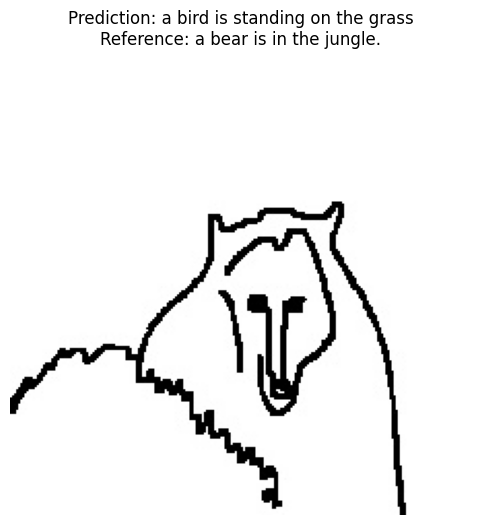

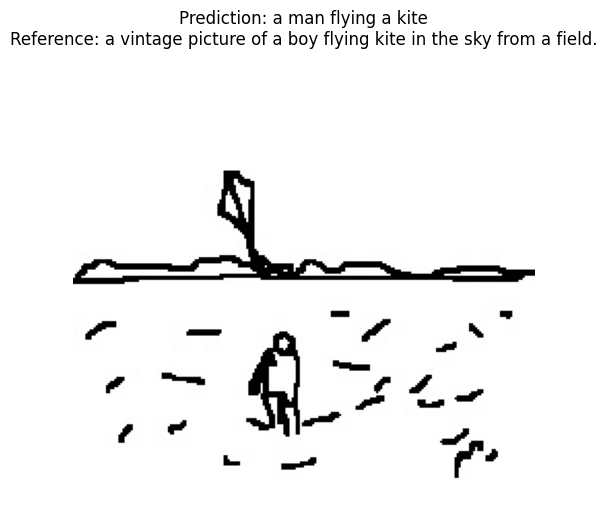

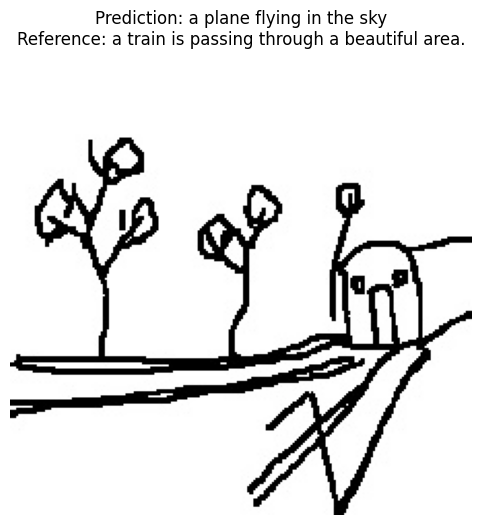

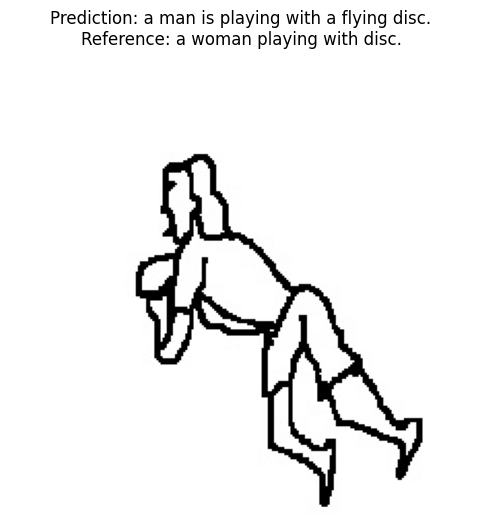

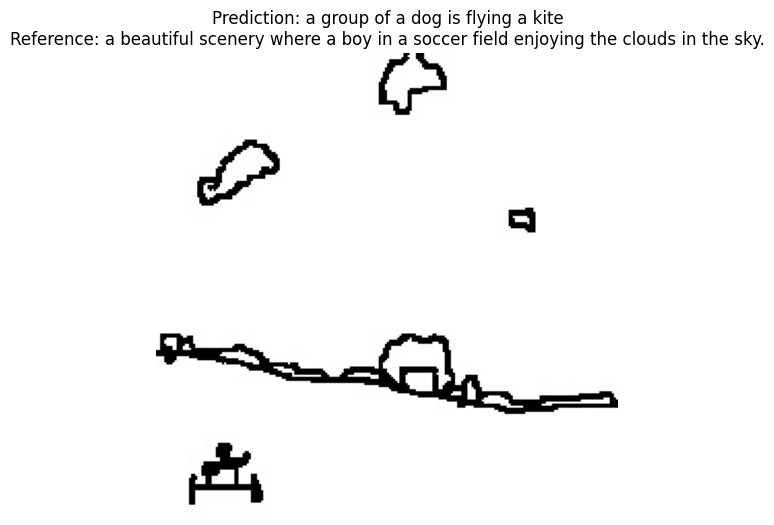

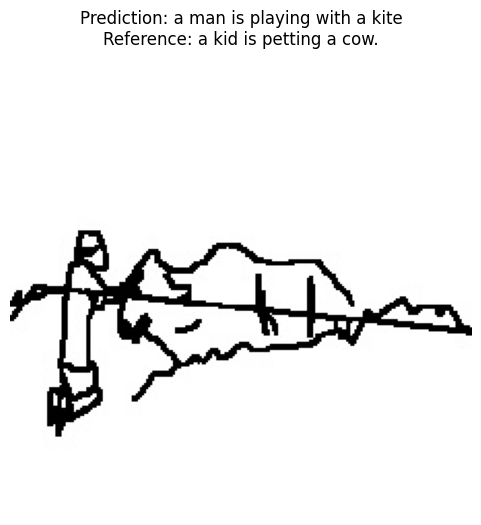

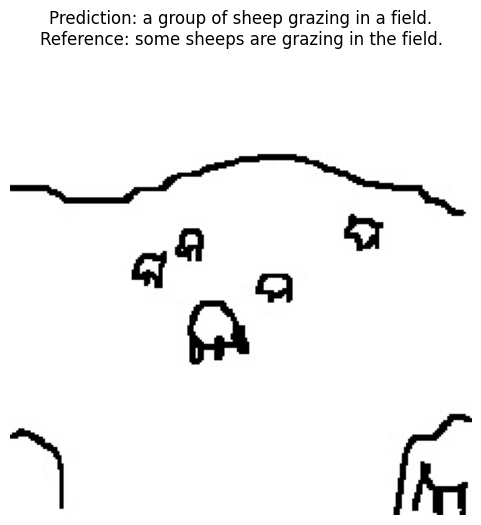

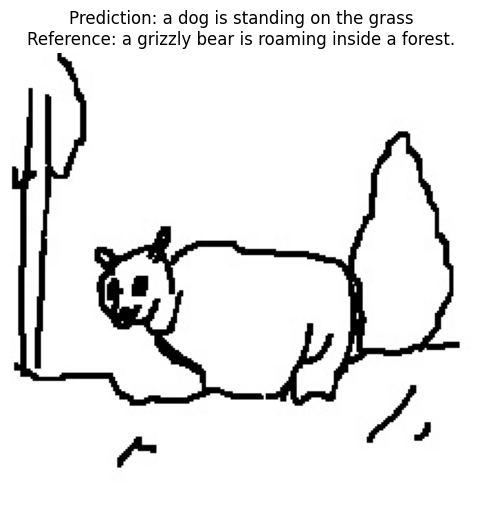

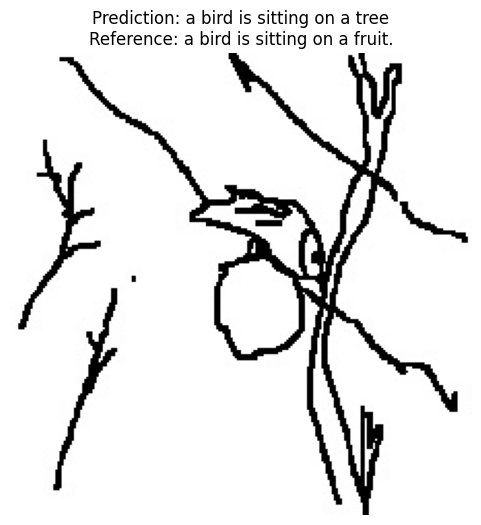

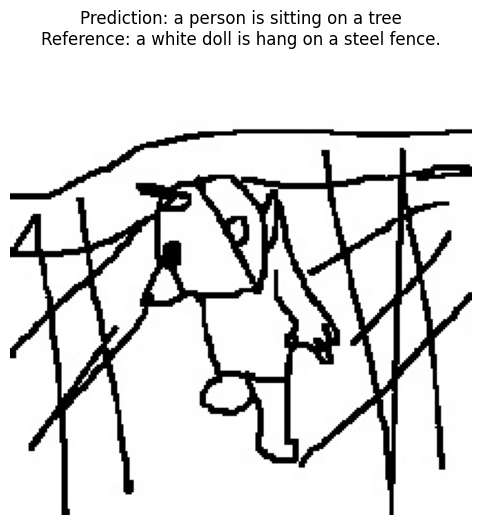

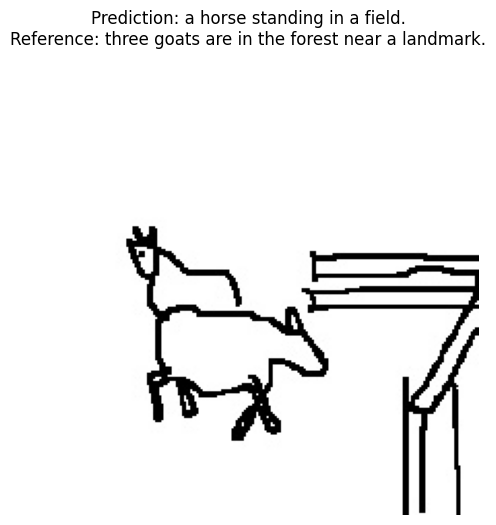

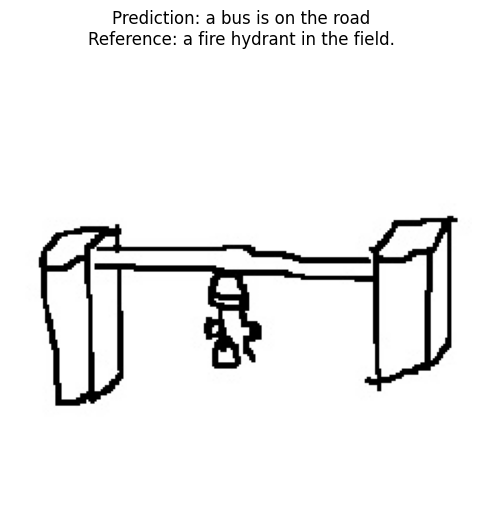

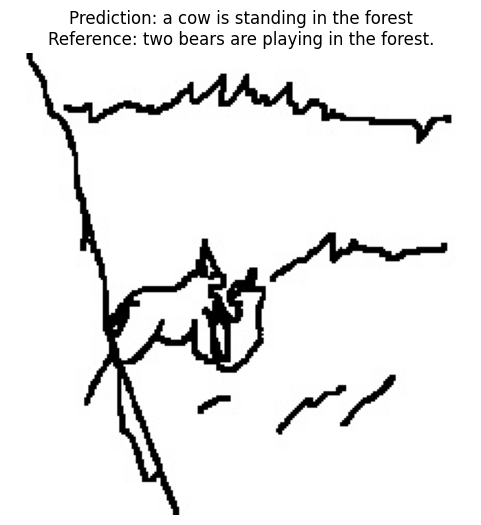

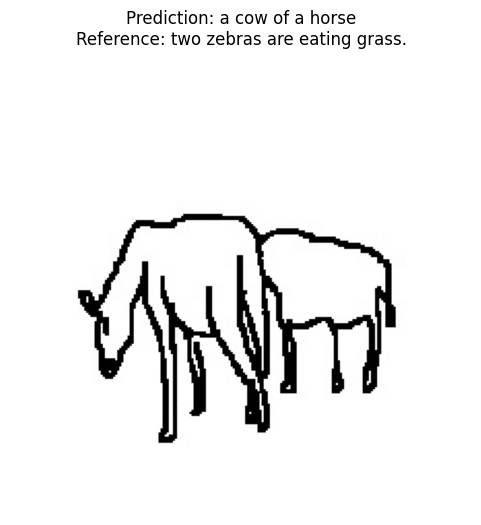

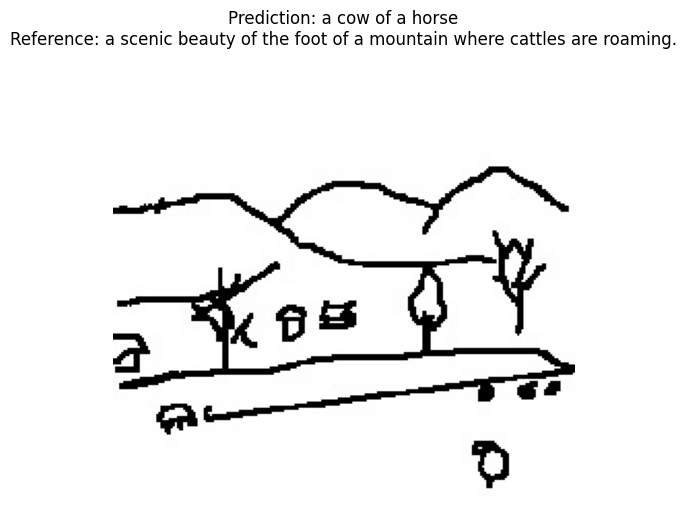

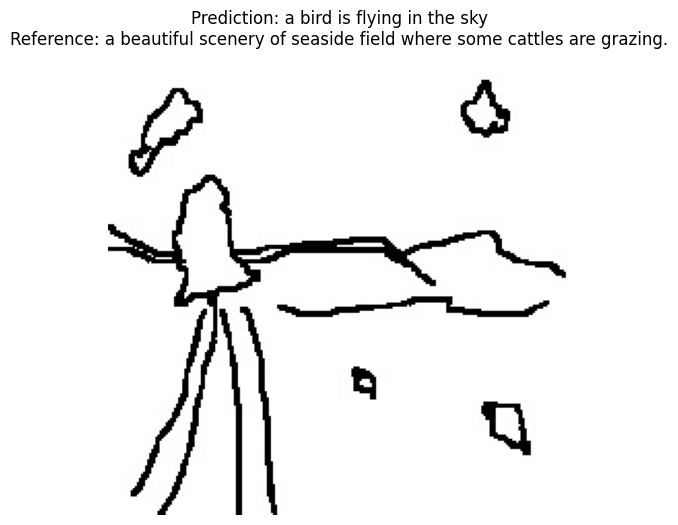

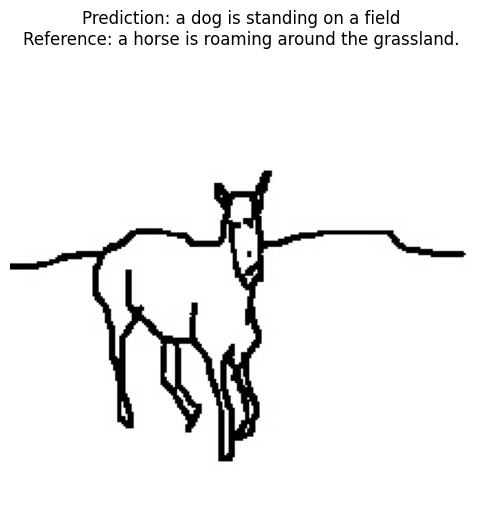

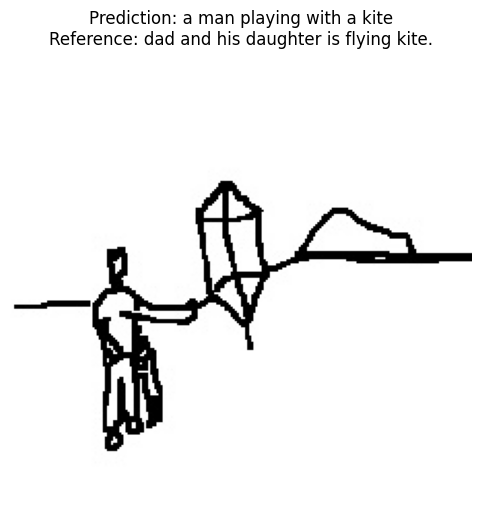

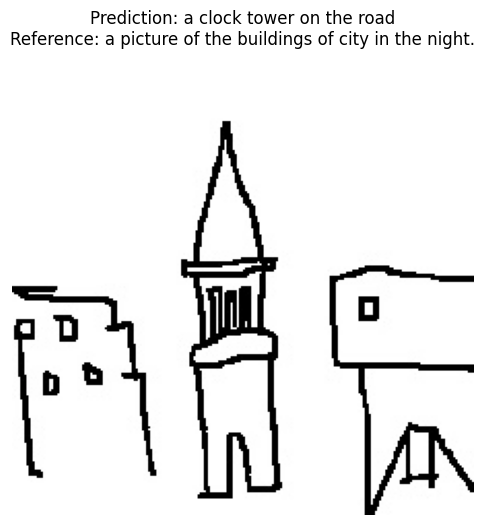

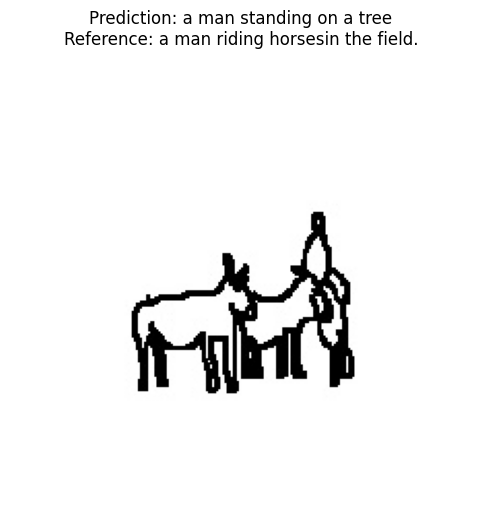

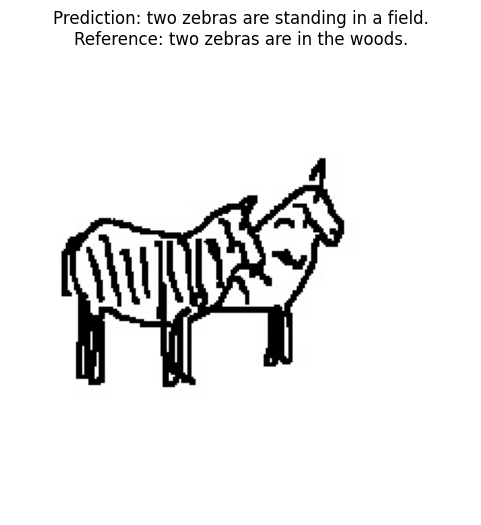

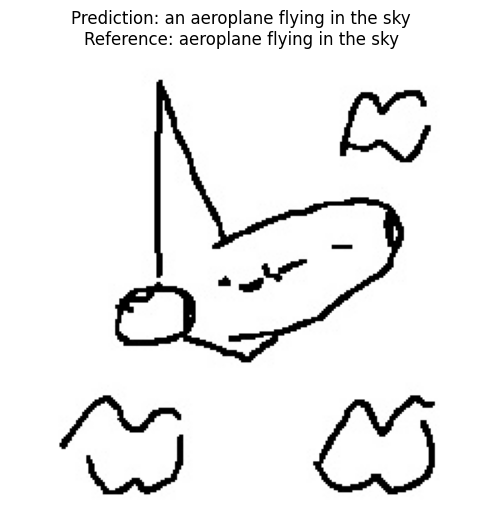

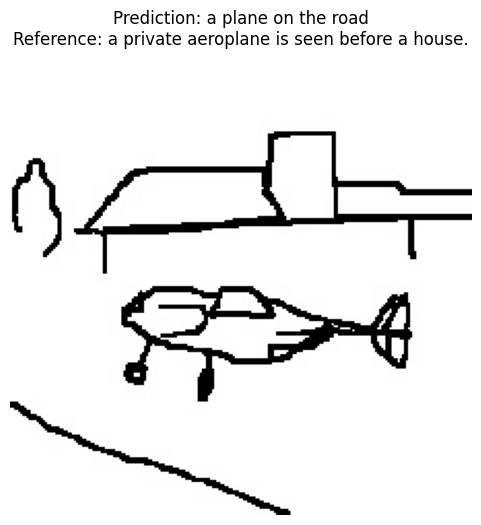

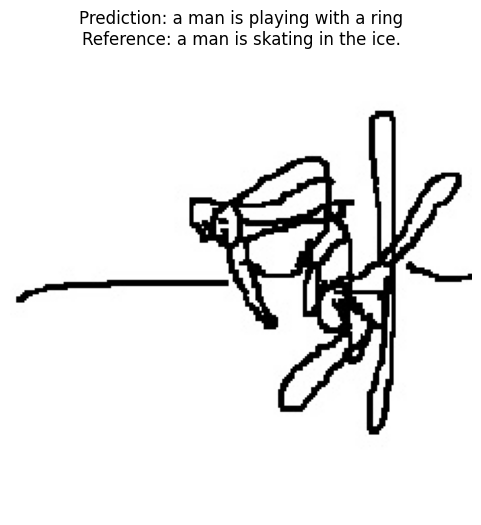

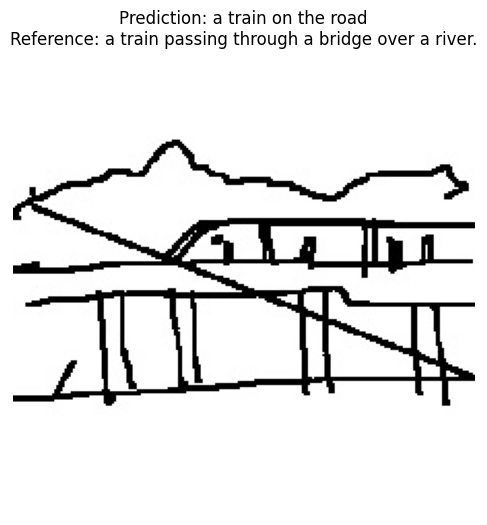

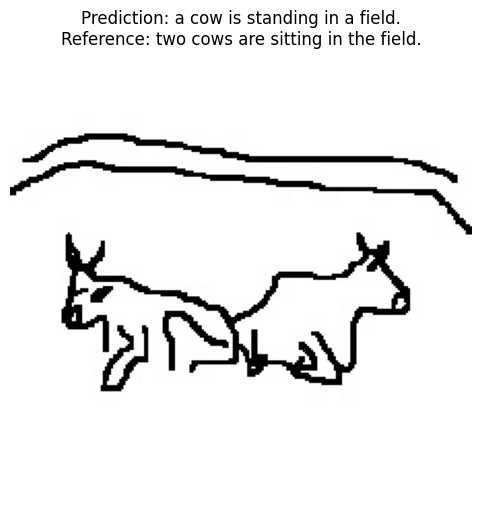

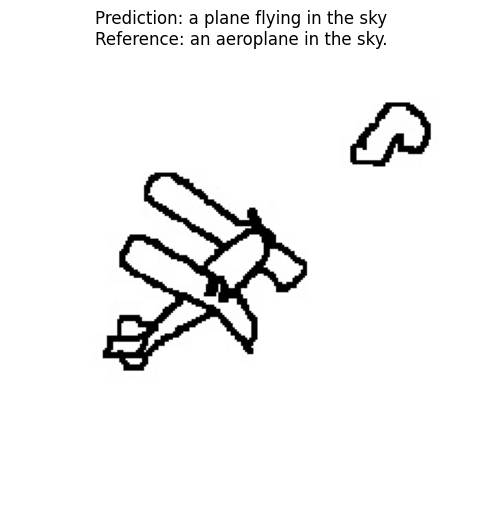

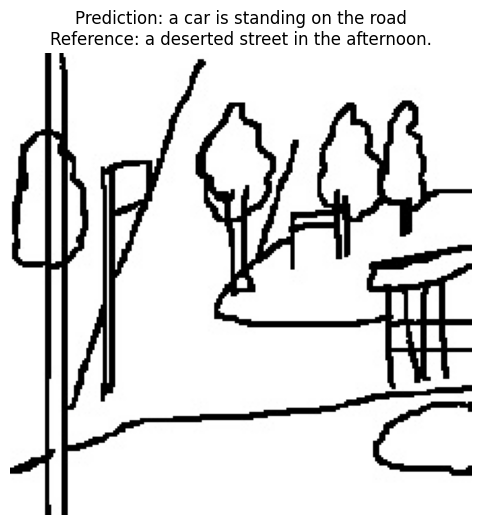

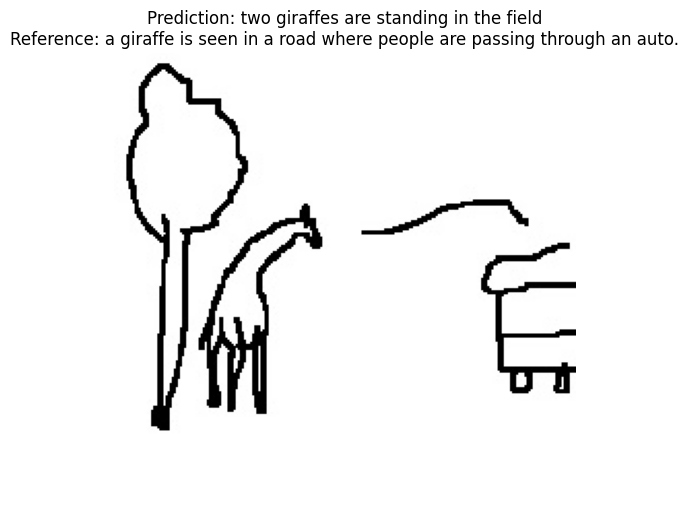

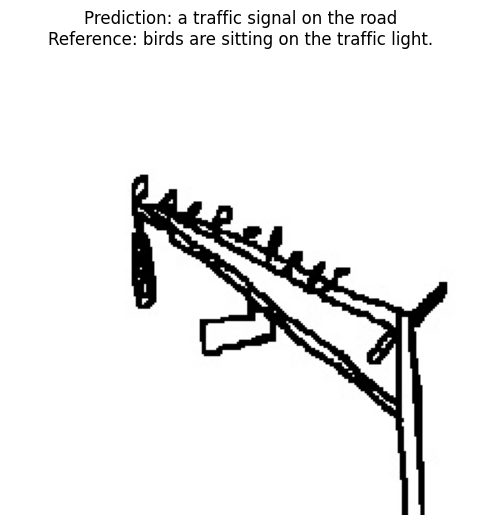

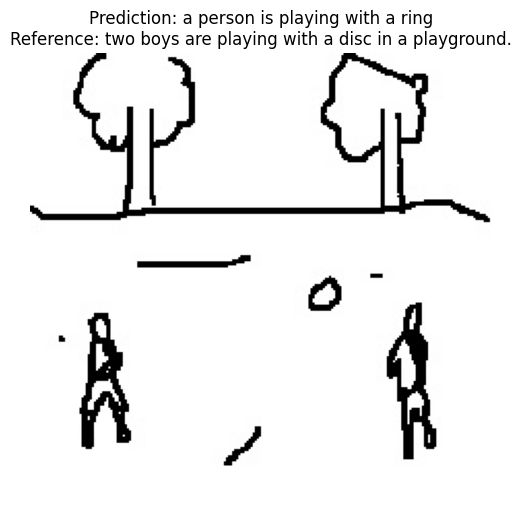

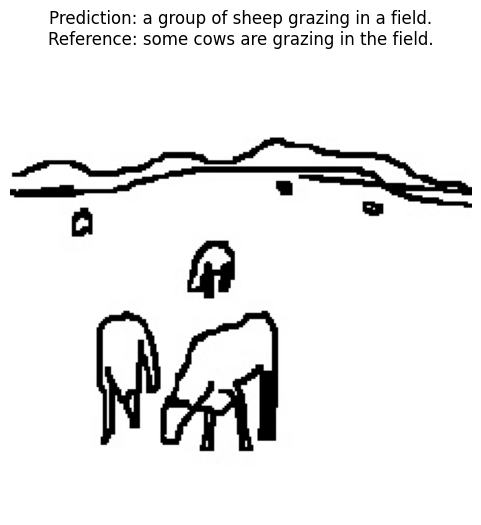

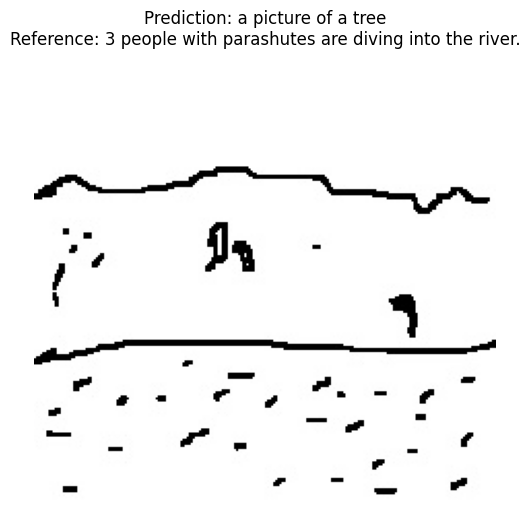

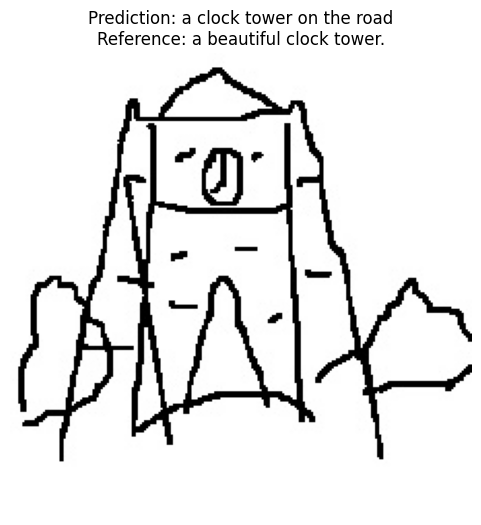

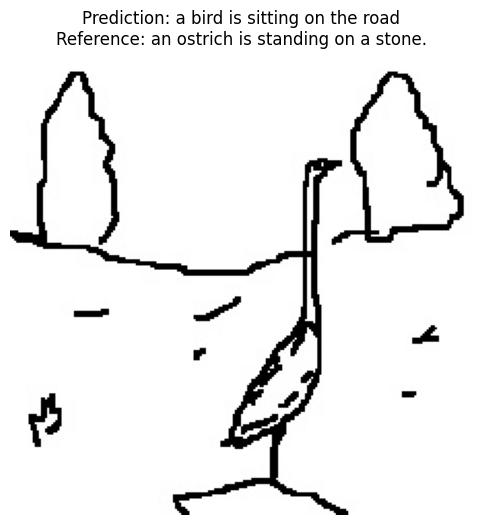

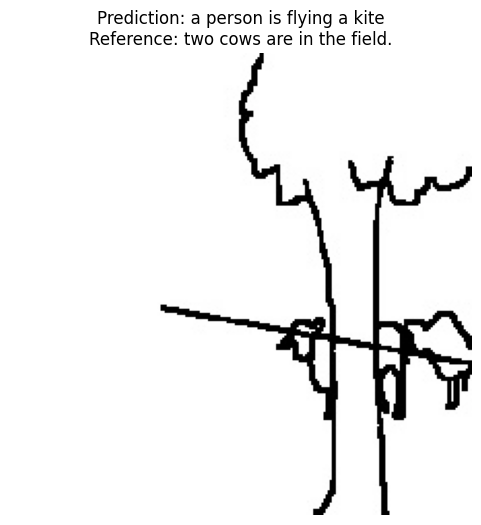

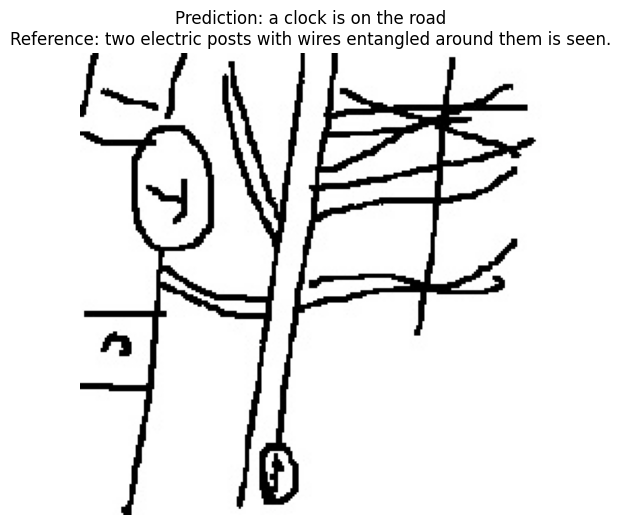

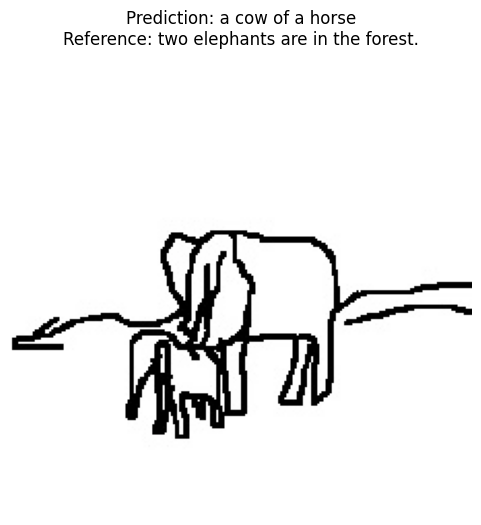

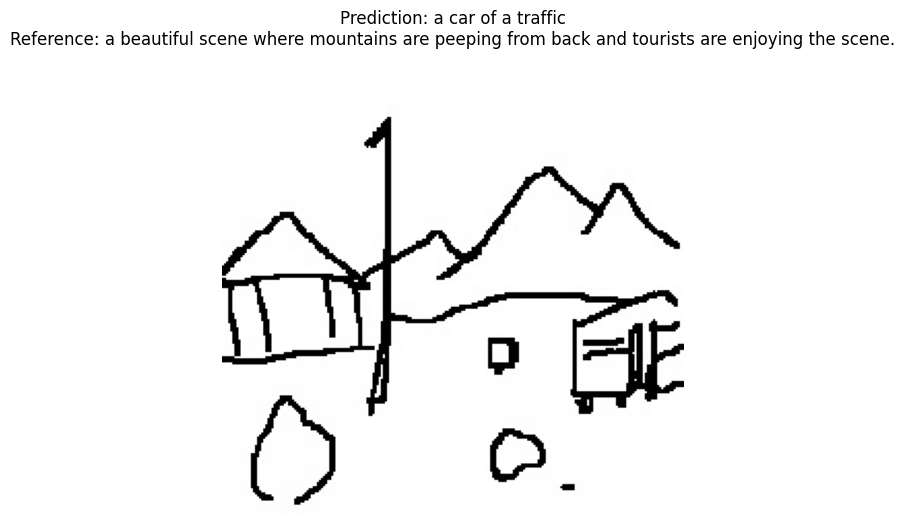

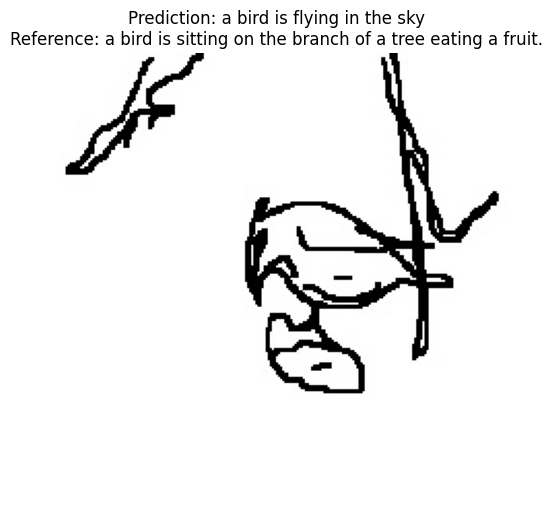

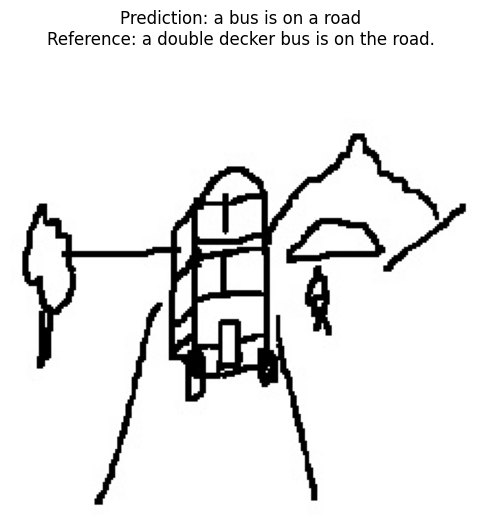

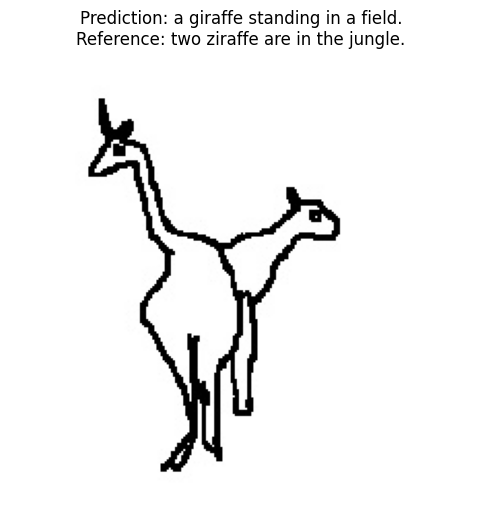

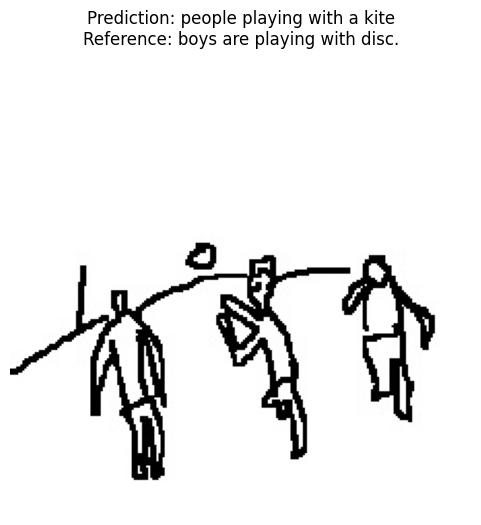

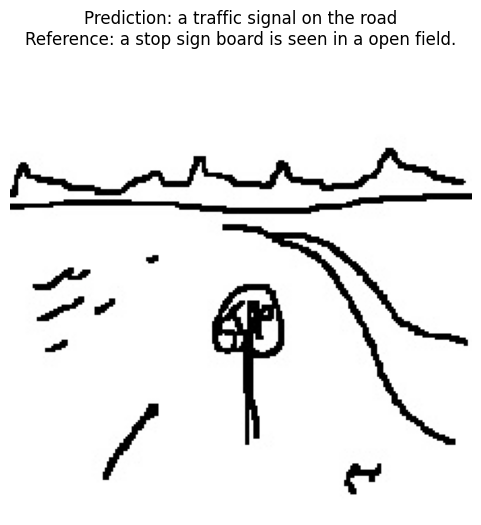

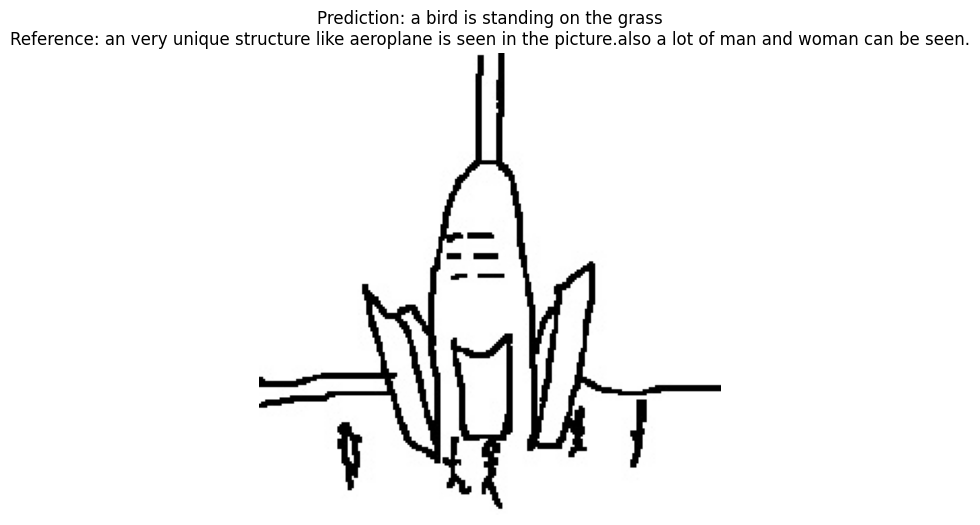

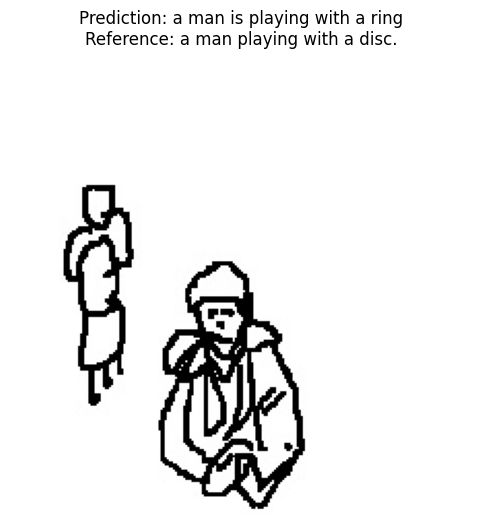

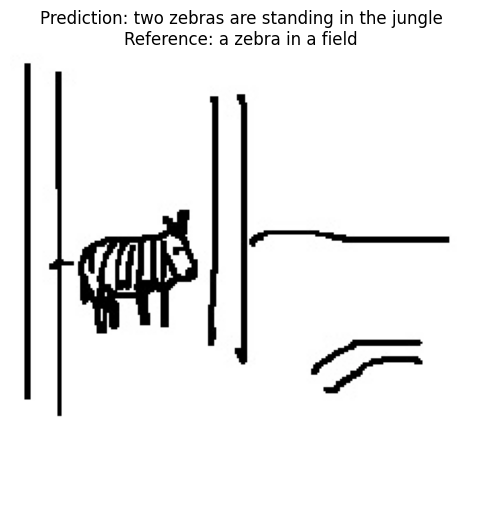

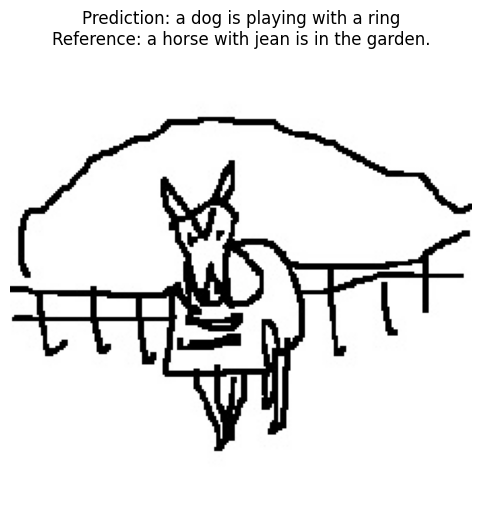

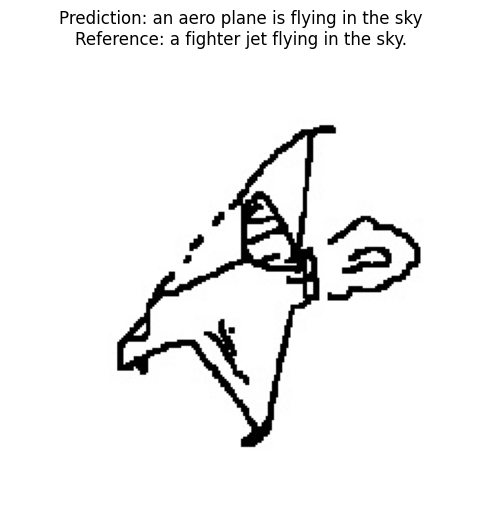

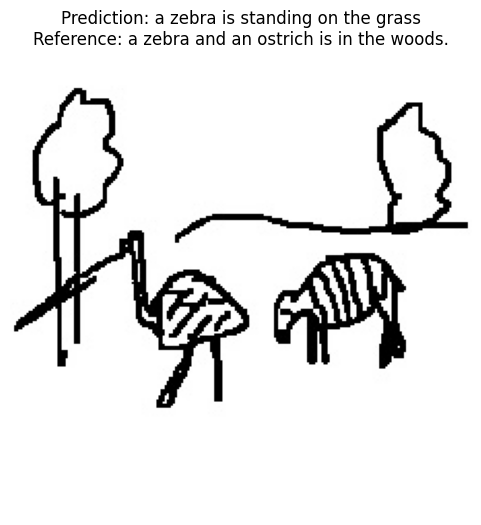

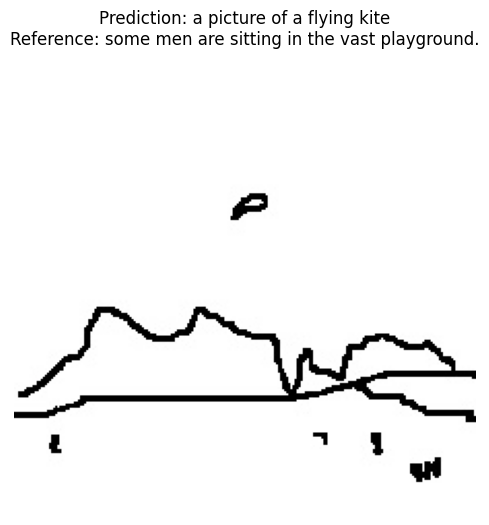

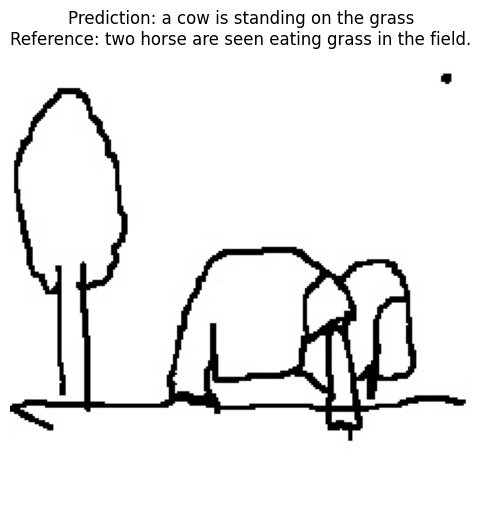

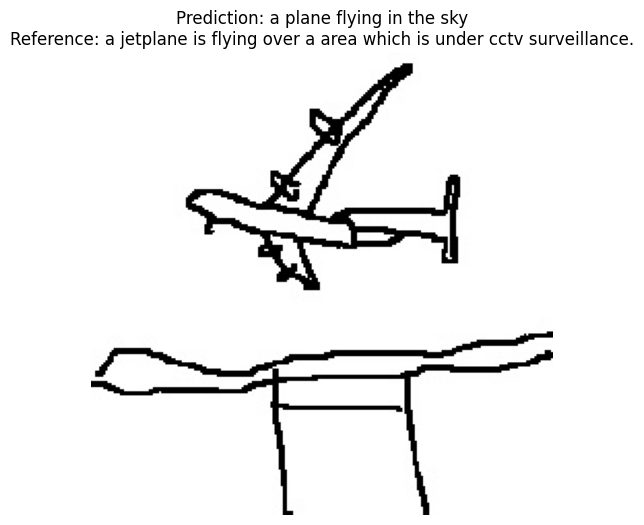

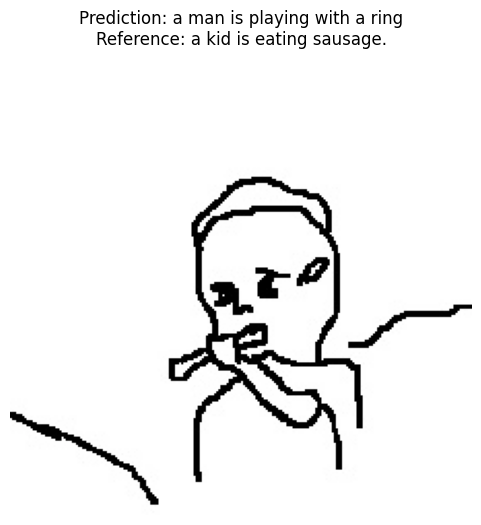

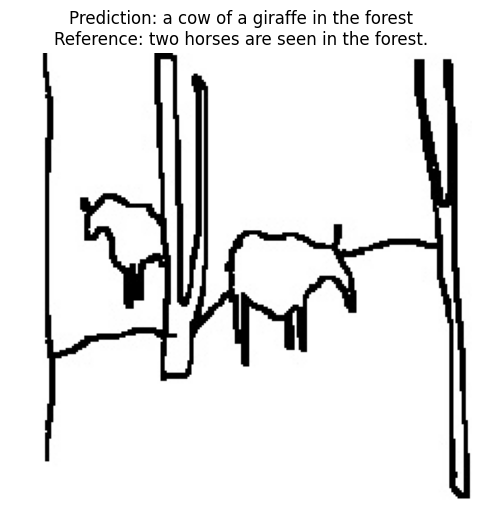

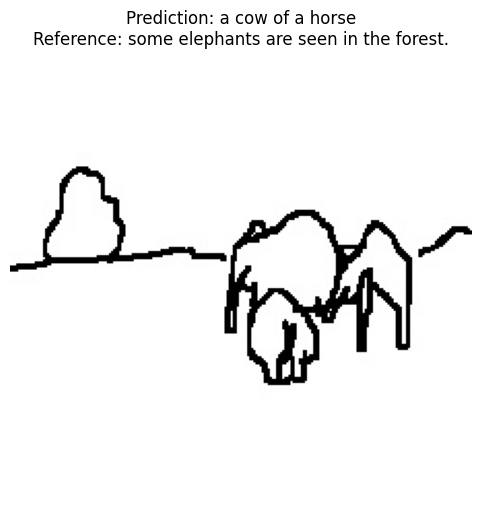

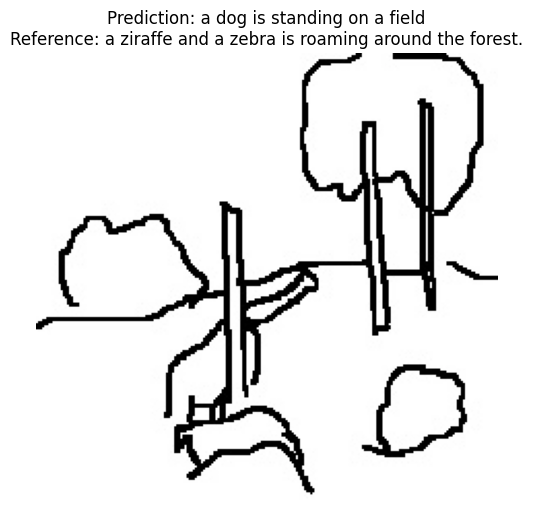

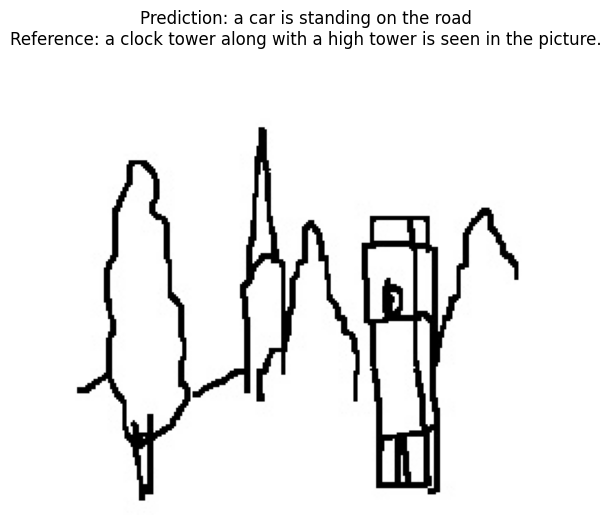

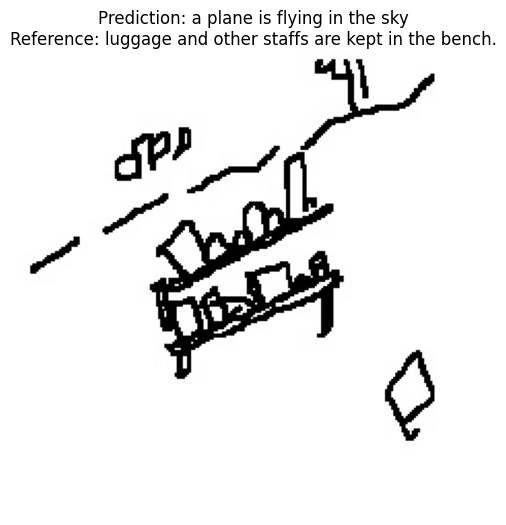

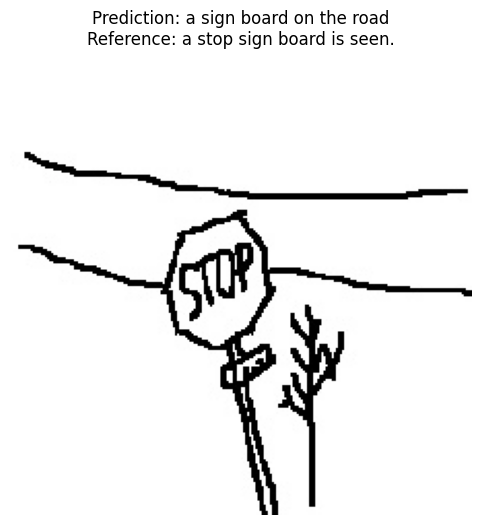

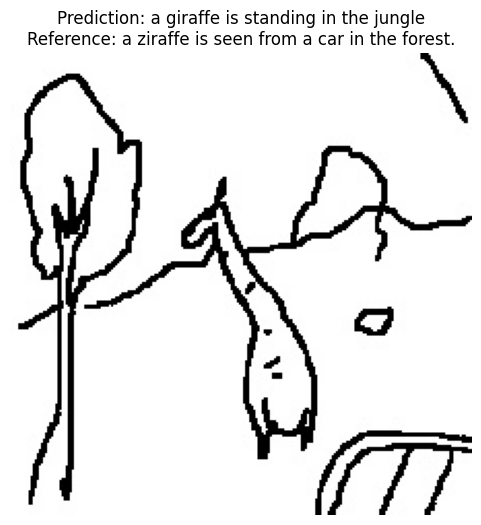

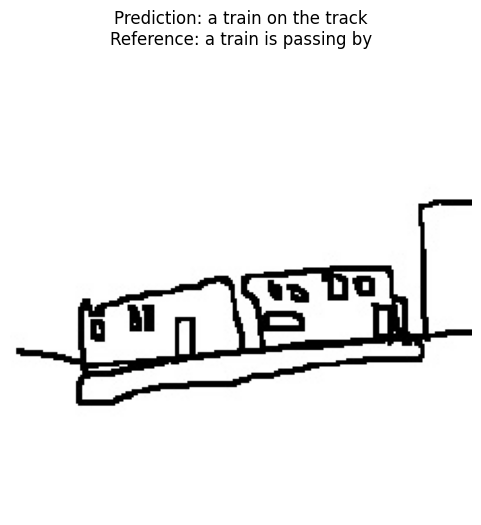

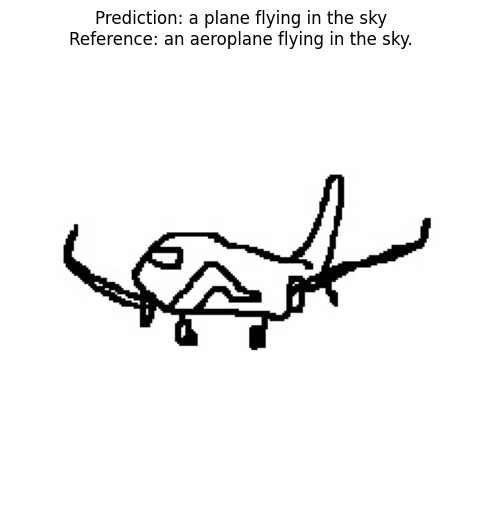

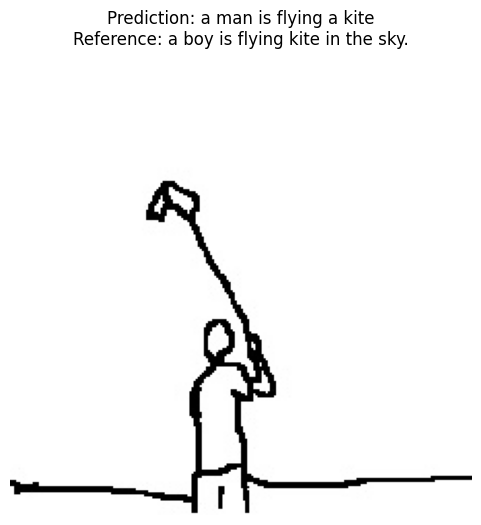

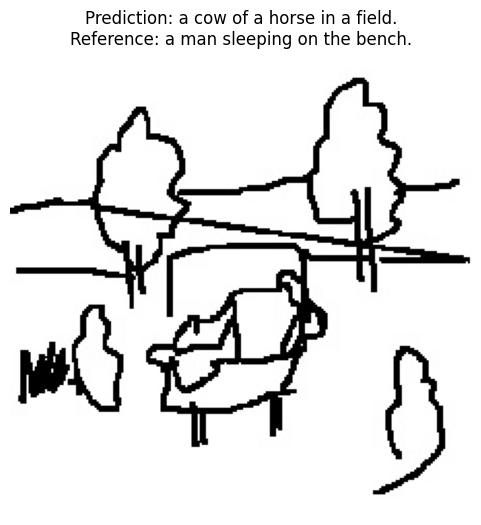

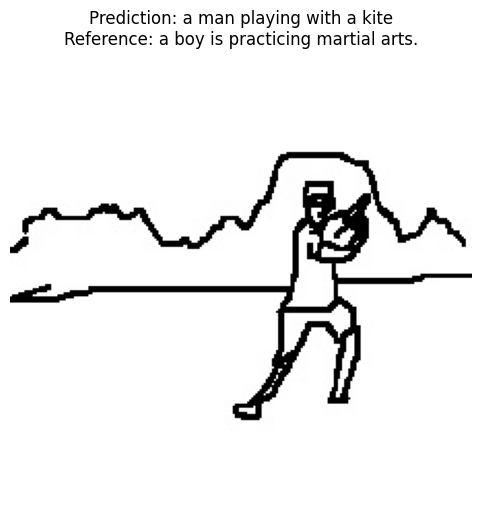

In [ ]:
import matplotlib.pyplot as plt
import torch

# Helper function to denormalize images for visualization.
def denormalize(image_tensor):
    device = image_tensor.device
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
    return image_tensor * std + mean

# Set model to evaluation mode
model.eval()

# Number of test samples to display
num_samples_to_display = 100
displayed = 0

with torch.no_grad():
    for images, captions, lengths in test_loader:
        images = images.to(device)
        for i in range(images.size(0)):
            # Generate prediction for a single image
            feat = model.encoder(images[i].unsqueeze(0))
            pred_caption = model.decoder.generate_caption_beam(feat, max_length=30, beam_size=1)

            # Process reference caption: decode the tensor into a human-readable string.
            ref_caption_idx = captions[i].tolist()
            ref_words = []
            for token in ref_caption_idx:
                if token == vocab.word2idx[EOS_TOKEN] or token == vocab.word2idx[PAD_TOKEN]:
                    break
                if token != vocab.word2idx[SOS_TOKEN]:
                    ref_words.append(vocab.idx2word[token])
            ref_caption = " ".join(ref_words)

            # Denormalize image for display
            image_denorm = denormalize(images[i]).clamp(0, 1)
            image_np = image_denorm.permute(1, 2, 0).cpu().numpy()

            # Display the image with both predicted and reference captions as title
            plt.figure(figsize=(6, 6))
            plt.imshow(image_np)
            plt.title(f"Prediction: {pred_caption}\nReference: {ref_caption}")
            plt.axis("off")
            plt.show()

            displayed += 1
            if displayed >= num_samples_to_display:
                break
        if displayed >= num_samples_to_display:
            break
